# 📊 Exploratory Data Analysis (EDA) — Airline Passenger Satisfaction
### Analisis Data Eksploratif Step-by-Step (Langkah 1 s.d. 15)

**Mata Kuliah:** Statistika & Probabilitas
**Sumber Dataset:** [Kaggle — Airline Passenger Satisfaction (teejmahal20)](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/data)
**Berkas yang dianalisis:** `train.csv` (data latih); `test.csv` dimuat pada Langkah 12 untuk menguji kelayakan pipeline.

---

### 👥 Anggota Kelompok & Pembagian Tugas

| No | Nama | NRP | Bagian | Langkah EDA |
|:--:|---|:--:|---|---|
| 1 | **Muhammad Rafi Purwanto** | 5027261119 | Bagian 1 — Pemahaman Data, Audit Kualitas & Nilai Hilang | Langkah 1 – 4 |
| 2 | **Andi Rinabil** | 5027261028 | Bagian 2 — Analisis Univariat & Bivariat | Langkah 5 – 7 |
| 3 | **Surakhbil Al Hasan** | 5027261070 | Bagian 3 — Deteksi Pencilan & Pemeriksaan Kualitas Lanjutan | Langkah 8 – 10 |
| 4 | **Nabil Ganendra Isbandi** | 5027261122 | Bagian 4 — Sintesis EDA, Pra-pemrosesan & Pengayaan | Langkah 11 – 15 |

### 🗺️ Peta Langkah

| Langkah | Judul | Penanggung Jawab |
|:--:|---|---|
| 1 | Load the dataset (dari Kaggle) & kamus data | Rafi |
| 2 | First look at the data | Rafi |
| 3 | Analyze data types | Rafi |
| 4 | Find categorical data | Rafi |
| 5 | Missing-value analysis (MCAR vs MAR) | Rinabil |
| 6 | Univariate analysis | Rinabil |
| 7 | Bivariate analysis | Rinabil |
| 8 | Outlier detection | Rakhbil |
| 9 | Data-quality checks beyond missing values & outliers | Rakhbil |
| 10 | Build an EDA summary | Rakhbil |
| 11 | Recommended preprocessing | Nabil |
| 12 | Example preprocessing implementation | Nabil |
| 13 | Final EDA checklist | Nabil |
| 14 | Student exercises | Nabil |
| 15 | Optional extension: reusable EDA helper | Nabil |

### 🎯 Tujuan Pembelajaran
Setelah menyelesaikan notebook ini kami mampu:
- membaca struktur dataset dan membedakan **tipe teknis** dengan **tipe analitis** setiap variabel,
- mendeteksi nilai hilang dan menilai mekanismenya (MCAR vs MAR) secara empiris,
- melakukan analisis univariat dan bivariat (disertai uji statistik sederhana),
- mengidentifikasi pencilan dengan metode visual, IQR, dan z-score serta memahami keterbatasannya,
- memeriksa kualitas data lanjutan: duplikasi, konsistensi label, nilai rating `0`, dan *confounding*,
- merangkum temuan menjadi tabel *Issue → Observation → Risk → Action* dan membangun pipeline pra-pemrosesan.

### 🧰 Cara Menjalankan
Jalankan **Kernel → Restart & Run All**. Dataset diunduh otomatis dari Kaggle memakai `kagglehub` (dataset publik, tidak butuh API key) sehingga diperlukan koneksi internet pada saat sel Langkah 1 dijalankan.

> 💡 **Catatan membaca notebook.** Angka pada kolom *Observation* ditulis berdasarkan hasil eksekusi pada `train.csv` yang sama. Sel interpretasi bertanda **🔎 Hasil otomatis** menghitung ulang angkanya langsung dari data, sehingga selalu konsisten dengan output di atasnya.

## ⚙️ Persiapan: Pustaka & Pengaturan Tampilan
Pustaka yang dipakai: `pandas`, `numpy` (manipulasi data), `matplotlib` & `seaborn` (visualisasi), serta `scipy.stats` (uji statistik). Palet warna dibuat konsisten: <span style="color:#E4572E">■</span> *neutral or dissatisfied*, <span style="color:#17BEBB">■</span> *satisfied*.

In [1]:
import os
import re
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.95)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# ---- Palet & urutan kategori (dipakai konsisten di seluruh notebook) ----
C_NEG, C_POS, C_MAIN = "#E4572E", "#17BEBB", "#2E4057"
SAT_ORDER = ["neutral or dissatisfied", "satisfied"]
PAL_SAT = {"neutral or dissatisfied": C_NEG, "satisfied": C_POS}
CLASS_ORDER = ["Eco", "Eco Plus", "Business"]
PAL_CLASS = {"Eco": "#E4572E", "Eco Plus": "#F4A259", "Business": "#17BEBB"}
BAR_TEAL = "rgba(23, 190, 187, 0.55)"
BAR_ORANGE = "rgba(228, 87, 46, 0.55)"


def gaya_tabel(tabel, hide_index=True):
    """Membungkus DataFrame menjadi tabel ber-header berwarna agar rapi dibaca."""
    sty = tabel.style
    if hide_index:
        sty = sty.hide(axis="index")
    return (
        sty.set_table_styles([
            {"selector": "th", "props": [("background-color", C_MAIN), ("color", "white"),
                                         ("text-align", "left"), ("padding", "6px 10px")]},
            {"selector": "td", "props": [("padding", "6px 10px")]},
        ])
        .set_properties(**{"text-align": "left"})
    )


print("Pustaka & pengaturan tampilan siap digunakan.")

Pustaka & pengaturan tampilan siap digunakan.


---
# BAGIAN 1 — PEMAHAMAN DATA, AUDIT KUALITAS & NILAI HILANG
**Penanggung Jawab: Muhammad Rafi Purwanto (NRP 5027261119)**

# 1. Load the dataset

Dataset diambil **langsung dari Kaggle** (`teejmahal20/airline-passenger-satisfaction`) menggunakan pustaka resmi `kagglehub`. Dataset berisi hasil survei kepuasan penumpang sebuah maskapai: tiap baris adalah **satu penumpang**, tiap kolom adalah profil penumpang, detail penerbangan, penilaian layanan, atau status kepuasan.

Kolom indeks sisa ekspor (`Unnamed: 0`) dibuang karena tidak membawa informasi.

In [2]:
# Pastikan kagglehub tersedia (otomatis dipasang bila belum ada)
try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub

KAGGLE_DATASET = "teejmahal20/airline-passenger-satisfaction"
path = kagglehub.dataset_download(KAGGLE_DATASET, force_download=True)
print("Dataset diunduh dari Kaggle ke :", path)


def cari_berkas(root, nama):
    """Mencari berkas `nama` di dalam folder hasil unduhan (termasuk sub-folder)."""
    for folder, _, files in os.walk(root):
        if nama in files:
            return os.path.join(folder, nama)
    raise FileNotFoundError(f"{nama} tidak ditemukan di {root}")


path_train = cari_berkas(path, "train.csv")
path_test = cari_berkas(path, "test.csv")
print("Berkas train :", path_train)
print("Berkas test  :", path_test)

# Memuat data latih (analisis utama) dan data uji (dipakai pada Langkah 12)
df = pd.read_csv(path_train).drop(columns=["Unnamed: 0"], errors="ignore")
df_test = pd.read_csv(path_test).drop(columns=["Unnamed: 0"], errors="ignore")

print(f"\ntrain.csv : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"test.csv  : {df_test.shape[0]:,} baris x {df_test.shape[1]} kolom")
df.head()

100%|██████████| 2.71M/2.71M [00:01<00:00, 1.80MB/s]

Extracting files...


Dataset diunduh dari Kaggle ke : C:\Users\Victus\.cache\kagglehub\datasets\teejmahal20\airline-passenger-satisfaction\versions\1
Berkas train : C:\Users\Victus\.cache\kagglehub\datasets\teejmahal20\airline-passenger-satisfaction\versions\1\train.csv
Berkas test  : C:\Users\Victus\.cache\kagglehub\datasets\teejmahal20\airline-passenger-satisfaction\versions\1\test.csv

train.csv : 103,904 baris x 24 kolom
test.csv  : 25,976 baris x 24 kolom


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.00,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.00,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.00,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.00,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.00,satisfied


In [3]:
import os
for p in [path_train, path_test]:
    with open(p, "rb") as f:
        awal = f.read(60)
    print(os.path.basename(p), "| ukuran:", round(os.path.getsize(p) / 1024**2, 2), "MB")
    print("   60 byte pertama:", awal, "\n")

train.csv | ukuran: 11.63 MB
   60 byte pertama: b',id,Gender,Customer Type,Age,Type of Travel,Class,Flight Dis' 

test.csv | ukuran: 2.9 MB
   60 byte pertama: b',id,Gender,Customer Type,Age,Type of Travel,Class,Flight Dis' 



### 📖 Kamus Data
Tabel berikut merangkum **seluruh 24 kolom** beserta tipe analitis dan skala pengukurannya. Skala rating `1–5` adalah tingkat kepuasan; nilai `0` berarti layanan *tidak berlaku / tidak digunakan* (dibahas pada Langkah 9).

In [4]:
kamus_data = pd.DataFrame([
    ("id", "Identifier", "-", "ID unik penumpang"),
    ("Gender", "Kategorikal", "Nominal", "Jenis kelamin penumpang (Female, Male)"),
    ("Customer Type", "Kategorikal", "Nominal", "Tipe loyalitas (Loyal Customer, disloyal Customer)"),
    ("Age", "Numerik diskrit", "Rasio", "Usia penumpang (tahun)"),
    ("Type of Travel", "Kategorikal", "Nominal", "Tujuan perjalanan (Business travel, Personal Travel)"),
    ("Class", "Kategorikal", "Ordinal", "Kelas kabin (Eco < Eco Plus < Business)"),
    ("Flight Distance", "Numerik kontinu", "Rasio", "Jarak penerbangan"),
    ("Inflight wifi service", "Rating Likert", "Ordinal", "Kepuasan wifi di pesawat"),
    ("Departure/Arrival time convenient", "Rating Likert", "Ordinal", "Kepuasan kenyamanan waktu berangkat/tiba"),
    ("Ease of Online booking", "Rating Likert", "Ordinal", "Kepuasan kemudahan pemesanan online"),
    ("Gate location", "Rating Likert", "Ordinal", "Kepuasan lokasi gerbang"),
    ("Food and drink", "Rating Likert", "Ordinal", "Kepuasan makanan & minuman"),
    ("Online boarding", "Rating Likert", "Ordinal", "Kepuasan boarding online"),
    ("Seat comfort", "Rating Likert", "Ordinal", "Kepuasan kenyamanan kursi"),
    ("Inflight entertainment", "Rating Likert", "Ordinal", "Kepuasan hiburan dalam pesawat"),
    ("On-board service", "Rating Likert", "Ordinal", "Kepuasan layanan di kabin"),
    ("Leg room service", "Rating Likert", "Ordinal", "Kepuasan ruang kaki"),
    ("Baggage handling", "Rating Likert", "Ordinal", "Kepuasan penanganan bagasi"),
    ("Checkin service", "Rating Likert", "Ordinal", "Kepuasan layanan check-in"),
    ("Inflight service", "Rating Likert", "Ordinal", "Kepuasan layanan selama penerbangan"),
    ("Cleanliness", "Rating Likert", "Ordinal", "Kepuasan kebersihan"),
    ("Departure Delay in Minutes", "Numerik kontinu", "Rasio", "Keterlambatan keberangkatan (menit)"),
    ("Arrival Delay in Minutes", "Numerik kontinu", "Rasio", "Keterlambatan kedatangan (menit)"),
    ("satisfaction", "Target biner", "Nominal", "Kepuasan (satisfied vs neutral or dissatisfied)"),
], columns=["Variabel", "Tipe analitis", "Skala ukur", "Keterangan"])

# Verifikasi: kamus harus tepat mencakup seluruh kolom data
assert list(kamus_data["Variabel"]) == list(df.columns), "Kamus data tidak sesuai dengan kolom dataset!"
display(gaya_tabel(kamus_data))

Variabel,Tipe analitis,Skala ukur,Keterangan
id,Identifier,-,ID unik penumpang
Gender,Kategorikal,Nominal,"Jenis kelamin penumpang (Female, Male)"
Customer Type,Kategorikal,Nominal,"Tipe loyalitas (Loyal Customer, disloyal Customer)"
Age,Numerik diskrit,Rasio,Usia penumpang (tahun)
Type of Travel,Kategorikal,Nominal,"Tujuan perjalanan (Business travel, Personal Travel)"
Class,Kategorikal,Ordinal,Kelas kabin (Eco < Eco Plus < Business)
Flight Distance,Numerik kontinu,Rasio,Jarak penerbangan
Inflight wifi service,Rating Likert,Ordinal,Kepuasan wifi di pesawat
Departure/Arrival time convenient,Rating Likert,Ordinal,Kepuasan kenyamanan waktu berangkat/tiba
Ease of Online booking,Rating Likert,Ordinal,Kepuasan kemudahan pemesanan online


# 2. First look at the data

Eksplorasi dimulai dari lima pertanyaan dasar:
1. Berapa baris dan kolom data ini?
2. Seperti apa bentuk baris-baris awal dan sampel acaknya?
3. Apakah nama kolom mudah dipahami dan konsisten?
4. Tipe data apa yang dibaca `pandas` secara default?
5. Adakah nilai yang tampak mencurigakan secara kasat mata?

In [5]:
ringkasan_awal = pd.DataFrame({
    "Pemeriksaan": ["Jumlah baris", "Jumlah kolom", "Ukuran memori (MB)", "Total sel kosong (NaN)",
                    "Baris duplikat penuh", "Kolom bertipe numerik", "Kolom bertipe teks"],
    "Nilai": [
        f"{df.shape[0]:,}", f"{df.shape[1]}", f"{df.memory_usage(deep=True).sum() / 1024**2:,.2f}",
        f"{int(df.isna().sum().sum()):,}", f"{int(df.duplicated().sum()):,}",
        f"{sum(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns)}",
        f"{sum(not pd.api.types.is_numeric_dtype(df[c]) for c in df.columns)}",
    ],
})
display(gaya_tabel(ringkasan_awal))

print("\nNama kolom:")
print(df.columns.tolist())

Pemeriksaan,Nilai
Jumlah baris,"103,904"
Jumlah kolom,24
Ukuran memori (MB),45.01
Total sel kosong (NaN),310
Baris duplikat penuh,0
Kolom bertipe numerik,19
Kolom bertipe teks,5



Nama kolom:
['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [6]:
print("--- 5 baris pertama (df.head) ---")
display(df.head())

print("\n--- 5 baris sampel acak (df.sample, random_state=42) ---")
display(df.sample(5, random_state=42))

print("\n--- 3 baris terakhir (df.tail) ---")
display(df.tail(3))

--- 5 baris pertama (df.head) ---


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.00,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.00,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.00,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.00,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.00,satisfied



--- 5 baris sampel acak (df.sample, random_state=42) ---


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
80638,98687,Female,Loyal Customer,26,Personal Travel,Eco,861,2,4,2,5,5,2,5,5,5,4,4,3,5,5,0,0.00,neutral or dissatisfied
43398,80734,Male,Loyal Customer,22,Business travel,Business,393,3,5,5,5,3,3,3,3,1,1,3,2,3,3,0,16.00,neutral or dissatisfied
32751,5711,Female,Loyal Customer,59,Personal Travel,Eco,196,1,3,1,3,2,3,3,4,4,1,4,3,4,4,37,34.00,neutral or dissatisfied
33571,23035,Female,Loyal Customer,32,Personal Travel,Eco,1020,2,3,2,4,4,2,4,4,3,2,4,1,4,4,27,4.00,neutral or dissatisfied
71287,53962,Male,disloyal Customer,35,Business travel,Business,1117,2,2,2,1,2,2,5,2,2,2,3,2,2,2,0,0.00,neutral or dissatisfied



--- 3 baris terakhir (df.tail) ---


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,1,3,4,1,5,4,3,2,4,5,5,4,7,14.00,neutral or dissatisfied
103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,1,5,1,1,1,1,4,5,1,5,4,1,0,0.00,neutral or dissatisfied
103903,62567,Male,Loyal Customer,27,Business travel,Business,1723,1,3,3,3,1,1,1,1,1,1,4,4,3,1,0,0.00,neutral or dissatisfied


In [7]:
# Pemindaian cepat rentang nilai: adakah angka yang mencurigakan?
rentang = df.select_dtypes(include="number").agg(["min", "max"]).T
rentang.index.name = "kolom"
display(gaya_tabel(rentang.reset_index()).format(precision=2, thousands=","))

kolom,min,max
id,1.00,"129,880.00"
Age,7.00,85.00
Flight Distance,31.00,"4,983.00"
Inflight wifi service,0.00,5.00
Departure/Arrival time convenient,0.00,5.00
Ease of Online booking,0.00,5.00
Gate location,0.00,5.00
Food and drink,0.00,5.00
Online boarding,0.00,5.00
Seat comfort,0.00,5.00


### 🔎 Observasi awal
- Data memiliki **103.904 baris** dan **24 kolom** setelah kolom `Unnamed: 0` dibuang.
- Nama kolom cukup mudah dipahami, tetapi **tidak seragam** (ada spasi, tanda `/`, dan tanda `-`, mis. `Departure/Arrival time convenient`, `On-board service`). Pada tahap pemodelan sebaiknya nama kolom dirapikan.
- Seluruh rating berada pada rentang kecil (0–5), sedangkan `Flight Distance` dan kedua kolom *delay* berskala jauh lebih besar → perlu diperhatikan saat penskalaan fitur.
- Rating bernilai **`0`** muncul di beberapa kolom: perlu diselidiki, apakah ini nilai hilang atau makna khusus (Langkah 9).

# 3. Analyze data types

Tipe penyimpanan `pandas` (*storage type*) **tidak selalu sama** dengan tipe analitis dalam statistika:
- `id` bertipe integer, tetapi hanya **identifier**,
- `Class` bertipe teks, tetapi sebenarnya **ordinal** (`Eco < Eco Plus < Business`),
- 14 kolom layanan bertipe angka, tetapi secara analitis berskala **Likert/ordinal**,
- `satisfaction` bertipe teks, tetapi merupakan **target biner**.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  str    
 2   Customer Type                      103904 non-null  str    
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  str    
 5   Class                              103904 non-null  str    
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 non-null

In [9]:
ringkas_tipe = pd.DataFrame({
    "tipe_pandas": df.dtypes.astype(str),
    "n_unik": df.nunique(dropna=True),
    "hilang": df.isna().sum(),
    "hilang (%)": (df.isna().mean() * 100).round(2),
})
ringkas_tipe = ringkas_tipe.join(kamus_data.set_index("Variabel")[["Tipe analitis", "Skala ukur"]])
ringkas_tipe.index.name = "kolom"
display(gaya_tabel(ringkas_tipe.reset_index()).format(precision=2, thousands=","))

kolom,tipe_pandas,n_unik,hilang,hilang (%),Tipe analitis,Skala ukur
id,int64,"103,904",0,0.00,Identifier,-
Gender,str,2,0,0.00,Kategorikal,Nominal
Customer Type,str,2,0,0.00,Kategorikal,Nominal
Age,int64,75,0,0.00,Numerik diskrit,Rasio
Type of Travel,str,2,0,0.00,Kategorikal,Nominal
Class,str,3,0,0.00,Kategorikal,Ordinal
Flight Distance,int64,"3,802",0,0.00,Numerik kontinu,Rasio
Inflight wifi service,int64,6,0,0.00,Rating Likert,Ordinal
Departure/Arrival time convenient,int64,6,0,0.00,Rating Likert,Ordinal
Ease of Online booking,int64,6,0,0.00,Rating Likert,Ordinal


### Interpretasi analitis
Dari kamus data, 24 variabel dikelompokkan ke dalam empat kelompok analitis:

| Kelompok | Variabel |
|---|---|
| **Identifier** | `id` |
| **Numerik** | `Age`, `Flight Distance`, `Departure Delay in Minutes`, `Arrival Delay in Minutes` |
| **Kategorikal** | `Gender`, `Customer Type`, `Type of Travel`, `Class`, `satisfaction` |
| **Rating layanan (Likert 0–5)** | 14 aspek layanan (wifi, boarding, kursi, kebersihan, dst.) |

In [10]:
identifier_cols = ["id"]
numeric_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort", "Inflight entertainment",
    "On-board service", "Leg room service", "Baggage handling", "Checkin service",
    "Inflight service", "Cleanliness",
]

# Verifikasi: keempat kelompok harus saling lepas dan menutup seluruh kolom
semua = identifier_cols + numeric_cols + categorical_cols + rating_cols
assert len(rating_cols) == 14
assert len(semua) == len(set(semua)) == df.shape[1]
assert set(semua) == set(df.columns)

print("Identifier  :", identifier_cols)
print("Numerik     :", numeric_cols)
print("Kategorikal :", categorical_cols)
print(f"Rating      : {len(rating_cols)} layanan")
print("\nOK: seluruh", df.shape[1], "kolom terklasifikasi tanpa tumpang tindih.")

Identifier  : ['id']
Numerik     : ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Kategorikal : ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
Rating      : 14 layanan

OK: seluruh 24 kolom terklasifikasi tanpa tumpang tindih.


# 4. Find categorical data

Deteksi otomatis mengambil kolom bertipe teks. Namun **tinjauan manual tetap wajib**, karena kolom integer seperti 14 rating layanan (dan `id`) juga bukan variabel numerik "murni".

In [11]:
auto_categorical = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
auto_numeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

print("Terdeteksi otomatis sebagai KATEGORIKAL:", auto_categorical)
print("\nTerdeteksi otomatis sebagai NUMERIK    :", len(auto_numeric), "kolom")

# Kolom yang 'terlihat numerik' tetapi sebenarnya bukan variabel kontinu
menyesatkan = [c for c in auto_numeric if c in rating_cols + identifier_cols]
print(f"\nKolom numerik menurut mesin namun secara analitis ordinal/identifier: {len(menyesatkan)} kolom")
print("Koreksi manual ini penting agar rating tidak diperlakukan sebagai angka kontinu.")

Terdeteksi otomatis sebagai KATEGORIKAL: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Terdeteksi otomatis sebagai NUMERIK    : 19 kolom

Kolom numerik menurut mesin namun secara analitis ordinal/identifier: 15 kolom
Koreksi manual ini penting agar rating tidak diperlakukan sebagai angka kontinu.


## Inspect category values
Berikut frekuensi dan persentase setiap kategori pada seluruh variabel kategorikal.

In [12]:
tabel_kategori = pd.concat(
    {
        col: df[col].value_counts(dropna=False).rename_axis("kategori").to_frame("jumlah")
        .assign(persen=lambda t: t["jumlah"] / len(df) * 100)
        for col in categorical_cols
    },
    names=["variabel"],
).reset_index()

display(
    gaya_tabel(tabel_kategori)
    .format({"jumlah": "{:,}", "persen": "{:.2f}%"})
    .bar(subset=["persen"], color=BAR_TEAL, vmin=0, vmax=100)
)

variabel,kategori,jumlah,persen
Gender,Female,"52,727",50.75%
Gender,Male,"51,177",49.25%
Customer Type,Loyal Customer,"84,923",81.73%
Customer Type,disloyal Customer,"18,981",18.27%
Type of Travel,Business travel,"71,655",68.96%
Type of Travel,Personal Travel,"32,249",31.04%
Class,Business,"49,665",47.80%
Class,Eco,"46,745",44.99%
Class,Eco Plus,"7,494",7.21%
satisfaction,neutral or dissatisfied,"58,879",56.67%


## Sebaran skor 14 rating layanan
*Heatmap* di bawah menunjukkan persentase penumpang untuk setiap skor `0–5` pada tiap layanan. Kolom **Skor 0** menandai layanan yang tidak dinilai.

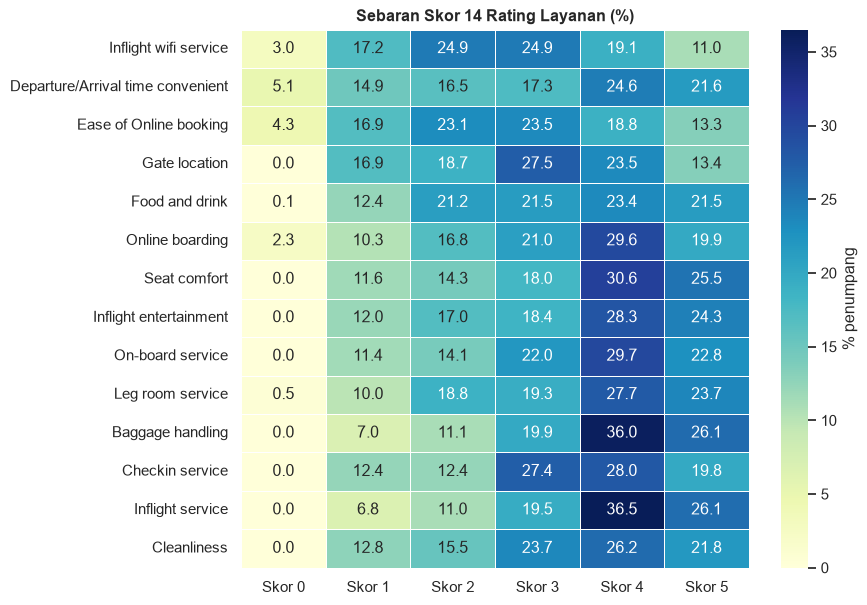

In [13]:
dist_rating = pd.DataFrame(
    {c: df[c].value_counts(normalize=True).reindex(range(6), fill_value=0) * 100 for c in rating_cols}
).T
dist_rating.columns = [f"Skor {i}" for i in range(6)]

plt.figure(figsize=(9, 6.2))
sns.heatmap(dist_rating, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5,
            cbar_kws={"label": "% penumpang"})
plt.title("Sebaran Skor 14 Rating Layanan (%)", fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 🔎 Observasi
1. **Gender** — hampir seimbang: 52.727 Female (50,7%) vs 51.177 Male (49,3%).
2. **Customer Type** — didominasi `Loyal Customer` (84.923; 81,7%) dibanding `disloyal Customer` (18.981; 18,3%).
3. **Type of Travel** — 71.655 penumpang (69,0%) bepergian untuk bisnis.
4. **Class** — `Business` 47,8%, `Eco` 45,0%, `Eco Plus` hanya 7,2% (kelas minoritas).
5. **Target `satisfaction`** — 56,7% *neutral or dissatisfied* vs 43,3% *satisfied*: cukup berimbang; *majority baseline* akurasi ≈ **56,7%**.
6. ⚠️ **Inkonsistensi penulisan label**: `disloyal Customer` diawali huruf kecil sedangkan `Loyal Customer` kapital; `Business travel` memakai huruf kecil pada "travel" sedangkan `Personal Travel` kapital. Perlu standardisasi (Langkah 11–12).
7. Label target `neutral or dissatisfied` **menggabungkan dua kondisi** (netral dan tidak puas) sehingga tidak dapat dipisahkan kembali.
8. Rating `0` banyak muncul pada beberapa layanan (terutama waktu berangkat/tiba, pemesanan online, wifi, dan online boarding), sedangkan `Baggage handling` tidak memiliki skor 0.

# 5. Missing-value analysis

Pertanyaan kunci:
- Kolom mana yang memiliki nilai hilang dan berapa persentasenya?
- Apakah hilangnya acak murni (**MCAR**) atau berkaitan dengan variabel lain (**MAR**)?
- Apakah lebih tepat menghapus baris, menghapus kolom, atau mengimputasi?

In [14]:
ringkas_hilang = pd.DataFrame({
    "jumlah_hilang": df.isna().sum(),
    "persen_hilang": df.isna().mean() * 100,
})
ringkas_hilang = ringkas_hilang[ringkas_hilang["jumlah_hilang"] > 0].sort_values("persen_hilang", ascending=False)
ringkas_hilang.index.name = "kolom"
display(gaya_tabel(ringkas_hilang.reset_index()).format({"jumlah_hilang": "{:,}", "persen_hilang": "{:.3f}%"}))

hilang_per_baris = df.isna().sum(axis=1)
print("Baris dengan >= 1 nilai hilang        :", f"{(hilang_per_baris > 0).sum():,}")
print("Maksimum nilai hilang dalam satu baris:", hilang_per_baris.max())

kolom,jumlah_hilang,persen_hilang
Arrival Delay in Minutes,310,0.298%


Baris dengan >= 1 nilai hilang        : 310
Maksimum nilai hilang dalam satu baris: 1


## Visualisasi nilai hilang per kolom

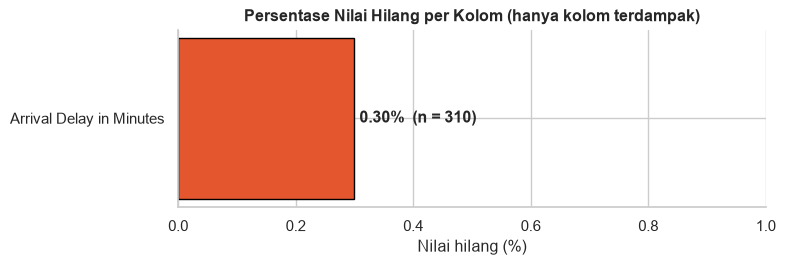

In [15]:
hilang_pct = ringkas_hilang["persen_hilang"]
fig, ax = plt.subplots(figsize=(8, 2.2 + 0.6 * len(hilang_pct)))
bars = ax.barh(hilang_pct.index, hilang_pct.values, color=C_NEG, edgecolor="black", height=0.45)
for b, (kol, n) in zip(bars, ringkas_hilang["jumlah_hilang"].items()):
    ax.text(b.get_width() + 0.01, b.get_y() + b.get_height() / 2,
            f"{b.get_width():.2f}%  (n = {n:,})", va="center", fontweight="bold")
ax.set_xlim(0, max(1.0, hilang_pct.max() * 1.5))
ax.set_xlabel("Nilai hilang (%)")
ax.set_title("Persentase Nilai Hilang per Kolom (hanya kolom terdampak)", fontweight="bold")
plt.tight_layout()
plt.show()

## Menguji mekanisme hilang: MCAR atau MAR?
Jika `Arrival Delay` hilang **secara acak murni (MCAR)**, maka karakteristik baris yang hilang seharusnya mirip dengan baris yang lengkap. Kami membandingkan **`Departure Delay`** (variabel yang selalu teramati) pada kedua kelompok, memakai uji **Mann–Whitney U** (non-parametrik, karena delay sangat menceng), serta memeriksa apakah tingkat kehilangan berbeda antar kategori.

In [16]:
kol_arr = "Arrival Delay in Minutes"
kol_dep = "Departure Delay in Minutes"

hilang = df[kol_arr].isna()
dep_hilang, dep_lengkap = df.loc[hilang, kol_dep], df.loc[~hilang, kol_dep]

tabel_mar = pd.DataFrame({
    "n baris": [dep_hilang.size, dep_lengkap.size],
    "rata-rata Departure Delay": [dep_hilang.mean(), dep_lengkap.mean()],
    "median": [dep_hilang.median(), dep_lengkap.median()],
    "persentil 90": [dep_hilang.quantile(.9), dep_lengkap.quantile(.9)],
}, index=["Arrival Delay HILANG", "Arrival Delay LENGKAP"])
tabel_mar.index.name = "kelompok"
display(gaya_tabel(tabel_mar.reset_index()).format(precision=2, thousands=","))

u, p = stats.mannwhitneyu(dep_hilang, dep_lengkap, alternative="two-sided")
print(f"Uji Mann-Whitney U: U = {u:,.0f}, p-value = {p:.3e}")

# Tingkat kehilangan per kategori
baris = []
for col in ["Class", "Customer Type", "Type of Travel", "satisfaction"]:
    t = df.groupby(col)[kol_arr].apply(lambda s: s.isna().mean() * 100)
    for kategori, nilai in t.items():
        baris.append({"variabel": col, "kategori": kategori, "% Arrival Delay hilang": nilai})
display(gaya_tabel(pd.DataFrame(baris)).format({"% Arrival Delay hilang": "{:.3f}%"}))

kelompok,n baris,rata-rata Departure Delay,median,persentil 90
Arrival Delay HILANG,310,37.43,8.00,118.10
Arrival Delay LENGKAP,"103,594",14.75,0.00,44.00


Uji Mann-Whitney U: U = 20,284,356, p-value = 8.504e-19


variabel,kategori,% Arrival Delay hilang
Class,Business,0.266%
Class,Eco,0.325%
Class,Eco Plus,0.347%
Customer Type,Loyal Customer,0.307%
Customer Type,disloyal Customer,0.258%
Type of Travel,Business travel,0.265%
Type of Travel,Personal Travel,0.372%
satisfaction,neutral or dissatisfied,0.309%
satisfaction,satisfied,0.284%


## Memilih strategi imputasi: median vs Departure Delay
Karena `Arrival Delay` sangat dekat dengan `Departure Delay` (kedua variabel mengukur keterlambatan pada penerbangan yang sama), kami membandingkan dua strategi imputasi pada baris yang **lengkap** dengan mengukur *Mean Absolute Error* (MAE) jika nilainya "disembunyikan" lalu ditebak.

In [17]:
lengkap = df.dropna(subset=[kol_arr])
mae_median = (lengkap[kol_arr] - lengkap[kol_arr].median()).abs().mean()
mae_dep = (lengkap[kol_arr] - lengkap[kol_dep]).abs().mean()

tabel_mae = pd.DataFrame({
    "Strategi imputasi": ["Median Arrival Delay", "Salin Departure Delay"],
    "MAE (menit)": [mae_median, mae_dep],
})
display(gaya_tabel(tabel_mae).format({"MAE (menit)": "{:.2f}"}).bar(subset=["MAE (menit)"], color=BAR_ORANGE))
print(f"Imputasi dengan Departure Delay ~{mae_median / mae_dep:.1f}x lebih akurat daripada median.")

Strategi imputasi,MAE (menit)
Median Arrival Delay,15.18
Salin Departure Delay,4.97


Imputasi dengan Departure Delay ~3.1x lebih akurat daripada median.


### 🔎 Interpretasi & keputusan
- Nilai hilang **hanya ada pada satu kolom**: `Arrival Delay in Minutes` — **310 baris (0,30%)**, dan setiap baris paling banyak kehilangan **satu** sel.
- Pada baris yang `Arrival Delay`-nya hilang, rata-rata `Departure Delay` adalah **37,43 menit**, sekitar **2,5 kali lipat** dibanding **14,75 menit** pada baris lengkap. Karena kehilangan berkaitan dengan variabel lain yang teramati, data **tidak konsisten dengan MCAR** dan lebih sesuai dengan **MAR**. *(Catatan: MAR vs MNAR tidak dapat dibuktikan hanya dari data yang teramati; MAR adalah kesimpulan kerja yang paling masuk akal.)*
- Perbandingan empiris: MAE imputasi **median = 15,18 menit** vs imputasi **Departure Delay = 4,97 menit** (≈ 3× lebih akurat).
- **Keputusan:** karena hanya 0,30% baris, **jangan menghapus baris**; **imputasi `Arrival Delay` dengan `Departure Delay`** pada baris yang sama.

> 📌 **Ringkasan Bagian 1.** Dataset cukup bersih secara struktural (tanpa baris duplikat dan hanya satu kolom bernilai hilang), namun terdapat tiga catatan penting yang dibawa ke langkah berikutnya: (1) label teks tidak konsisten, (2) satu kolom bernilai hilang berpola MAR, (3) rating `0` perlu diselidiki maknanya.

---
# BAGIAN 2 — ANALISIS UNIVARIAT & BIVARIAT
**Penanggung Jawab: Andi Rinabil (NRP 5027261028)**

# 6. Univariate analysis

Sebelum melihat hubungan antar-variabel, setiap variabel diperiksa **satu per satu**:
- **Numerik** → ukuran pemusatan (mean, median), sebaran (std, IQR), nilai ekstrem, bentuk distribusi (skewness, kurtosis), dan proporsi nilai nol.
- **Kategorikal** → frekuensi dan persentase tiap kategori.
- **Rating layanan** → profil skor rata-rata untuk mengetahui kekuatan dan kelemahan layanan.

In [18]:
def ringkas_numerik(data, cols):
    """Statistik deskriptif lengkap, termasuk skewness, kurtosis, % nol, dan koefisien variasi."""
    hasil = {}
    for c in cols:
        s = data[c].dropna()
        hasil[c] = {
            "n": s.size, "mean": s.mean(), "median": s.median(), "std": s.std(),
            "min": s.min(), "Q1": s.quantile(.25), "Q3": s.quantile(.75), "max": s.max(),
            "skewness": s.skew(), "kurtosis": s.kurt(),
            "% bernilai 0": (s == 0).mean() * 100, "CV (std/mean)": s.std() / s.mean(),
        }
    return pd.DataFrame(hasil).T


stat_numerik = ringkas_numerik(df, numeric_cols)
stat_numerik.index.name = "variabel"
display(
    gaya_tabel(stat_numerik.reset_index(), hide_index=True)
    .format(precision=2, thousands=",")
    .format({"n": "{:,.0f}"}, subset=["n"])
)

variabel,n,mean,median,std,min,Q1,Q3,max,skewness,kurtosis,% bernilai 0,CV (std/mean)
Age,"103,904",39.38,40.00,15.11,7.00,27.00,51.00,85.00,-0.00,-0.72,0.00,0.38
Flight Distance,"103,904","1,189.45",843.00,997.15,31.00,414.00,"1,743.00","4,983.00",1.11,0.27,0.00,0.84
Departure Delay in Minutes,"103,904",14.82,0.00,38.23,0.00,0.00,12.00,"1,592.00",6.73,100.27,56.46,2.58
Arrival Delay in Minutes,"103,594",15.18,0.00,38.70,0.00,0.00,13.00,"1,584.00",6.60,94.54,56.14,2.55


### Distribusi fitur numerik
Garis putus-putus merah menandai **mean** dan garis hijau menandai **median**. Jarak yang lebar antara keduanya menandakan distribusi menceng. Untuk variabel *delay*, tampilan dibatasi ≤ 150 menit agar bentuknya terlihat (nilai di atasnya tetap ada di data).

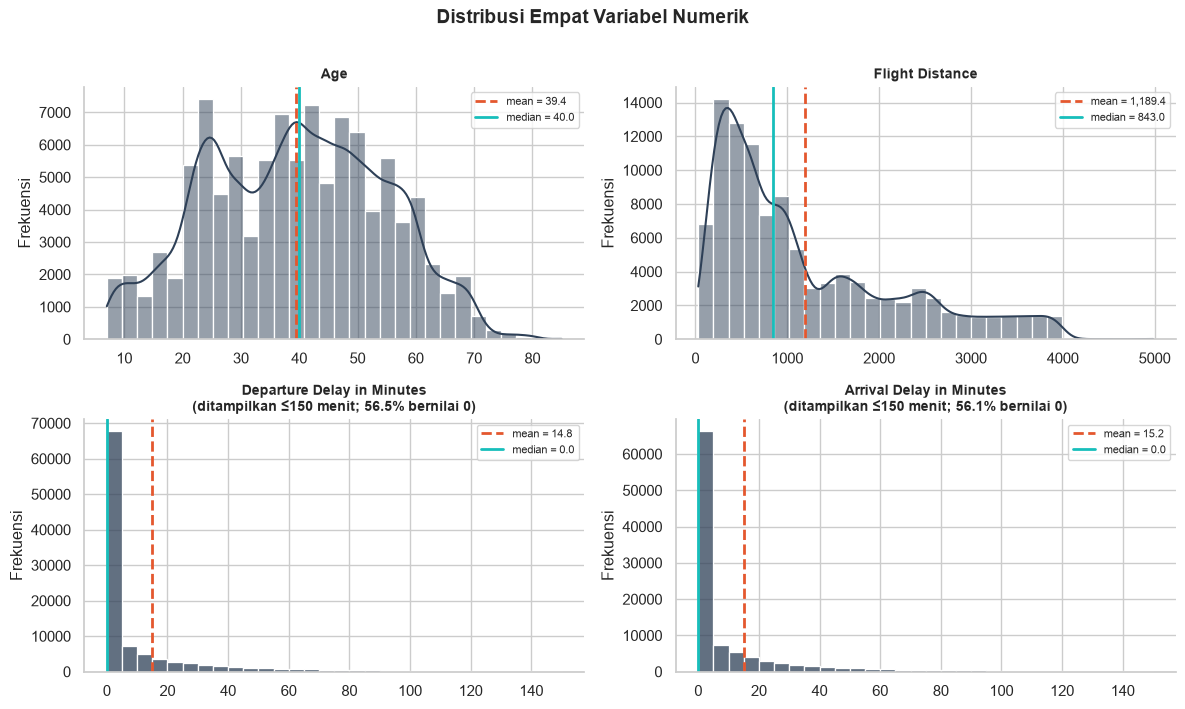

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.ravel(), numeric_cols):
    s = df[col].dropna()
    delay = "Delay" in col
    sns.histplot(s[s <= 150] if delay else s, bins=30, kde=not delay, color=C_MAIN, edgecolor="white", ax=ax)
    ax.axvline(s.mean(), color=C_NEG, ls="--", lw=2, label=f"mean = {s.mean():,.1f}")
    ax.axvline(s.median(), color=C_POS, ls="-", lw=2, label=f"median = {s.median():,.1f}")
    judul = f"{col}" + (f"\n(ditampilkan ≤150 menit; {(s == 0).mean() * 100:.1f}% bernilai 0)" if delay else "")
    ax.set_title(judul, fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8)
plt.suptitle("Distribusi Empat Variabel Numerik", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Frekuensi fitur kategorikal

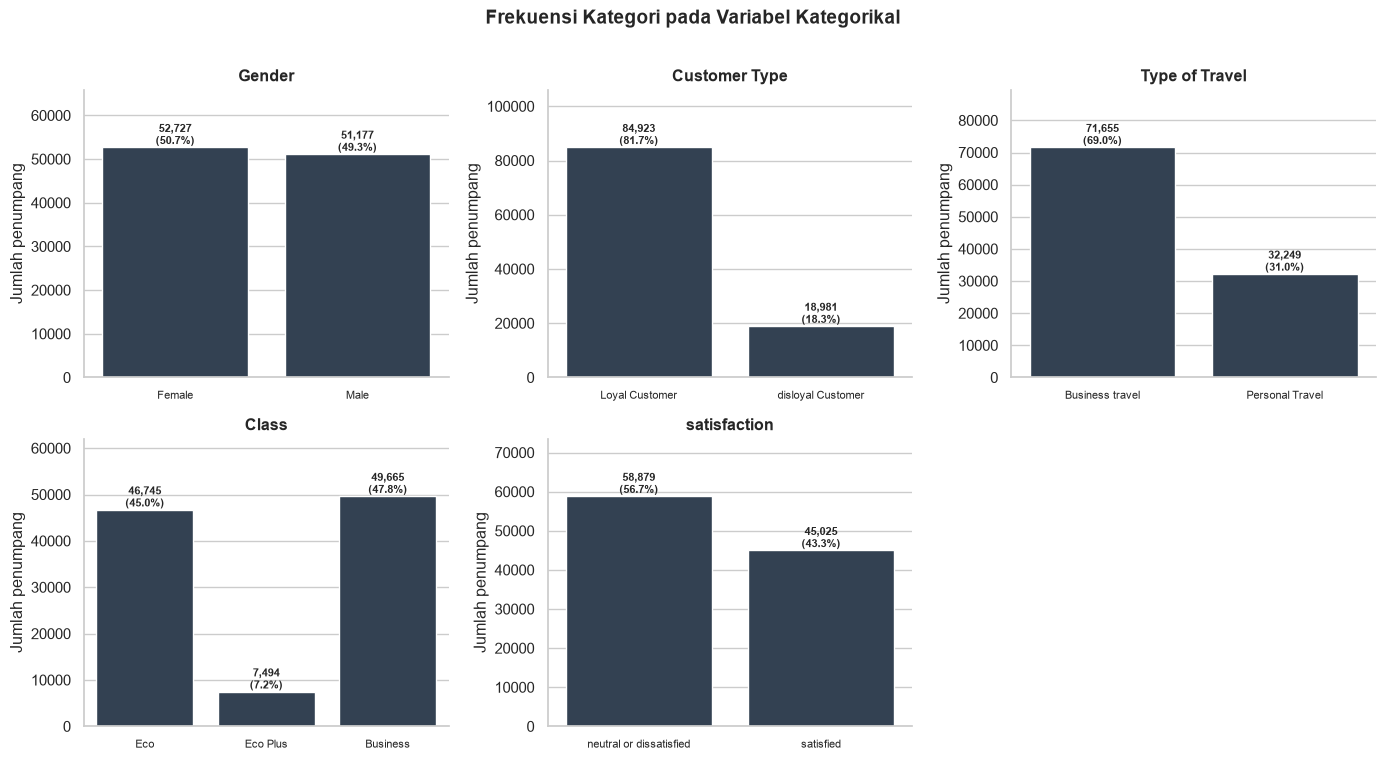

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
axes = axes.ravel()
for ax, col in zip(axes, categorical_cols):
    urutan = CLASS_ORDER if col == "Class" else df[col].value_counts().index
    sns.countplot(data=df, x=col, order=urutan, color=C_MAIN, edgecolor="white", ax=ax)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:,.0f}\n({h / len(df) * 100:.1f}%)", (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_ylim(0, max(pt.get_height() for pt in ax.patches) * 1.25)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Jumlah penumpang")
    ax.tick_params(axis="x", labelsize=8)
for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)
plt.suptitle("Frekuensi Kategori pada Variabel Kategorikal", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Profil skor rata-rata 14 layanan
Skor rata-rata dihitung **tanpa nilai 0** (karena `0` berarti tidak digunakan, bukan nilai buruk) sehingga tidak menarik rata-rata ke bawah.

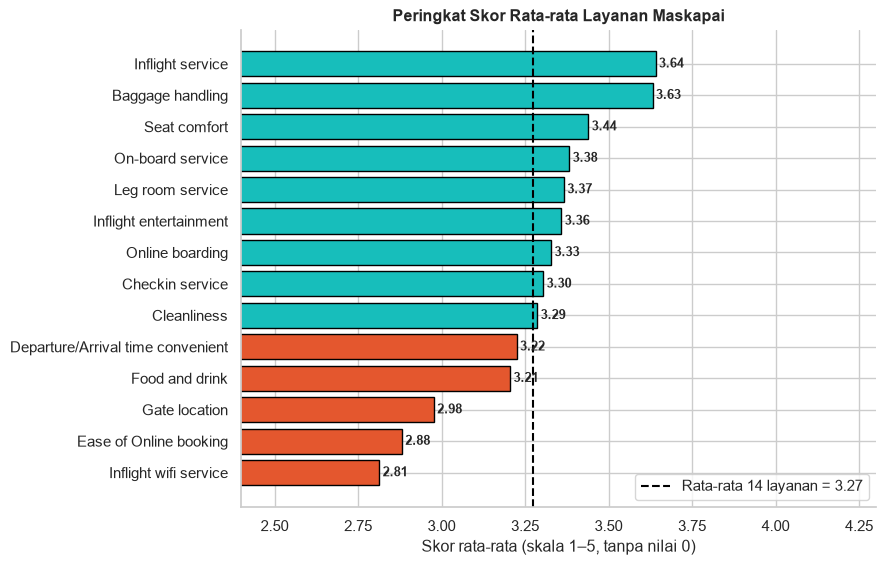

🔎 Hasil otomatis
Tiga layanan dengan skor terendah : Inflight wifi service (2.81), Ease of Online booking (2.88), Gate location (2.98)
Tiga layanan dengan skor tertinggi: Inflight service (3.64), Baggage handling (3.63), Seat comfort (3.44)


In [21]:
skor_layanan = pd.Series({c: df.loc[df[c] > 0, c].mean() for c in rating_cols}).sort_values()
rata_semua = skor_layanan.mean()

plt.figure(figsize=(9, 5.8))
warna = [C_NEG if v < rata_semua else C_POS for v in skor_layanan.values]
bars = plt.barh(skor_layanan.index, skor_layanan.values, color=warna, edgecolor="black")
plt.axvline(rata_semua, color="black", ls="--", label=f"Rata-rata 14 layanan = {rata_semua:.2f}")
for b in bars:
    plt.text(b.get_width() + 0.01, b.get_y() + b.get_height() / 2, f"{b.get_width():.2f}",
             va="center", fontweight="bold", fontsize=9)
plt.xlim(2.4, 4.3)
plt.xlabel("Skor rata-rata (skala 1–5, tanpa nilai 0)")
plt.title("Peringkat Skor Rata-rata Layanan Maskapai", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("🔎 Hasil otomatis")
print("Tiga layanan dengan skor terendah :", ", ".join(f"{k} ({v:.2f})" for k, v in skor_layanan.head(3).items()))
print("Tiga layanan dengan skor tertinggi:", ", ".join(f"{k} ({v:.2f})" for k, v in skor_layanan.tail(3)[::-1].items()))

### 🔎 Interpretasi univariat
- **Age:** rata-rata 39,38 tahun dan median 40 (hampir simetris), rentang 7–85 tahun.
- **Flight Distance:** rata-rata (1.189) **lebih besar** dari median (843) → menceng ke kanan; terdapat segelintir penerbangan sangat jauh (maks. 4.983).
- **Departure & Arrival Delay:** median **0 menit**, tetapi rata-rata 14,82 dan 15,18 menit dengan maksimum >1.500 menit → distribusi **zero-inflated** dengan ekor sangat panjang (lihat kolom *skewness* dan *% bernilai 0* pada tabel).
- Proporsi kategori sama dengan Langkah 4: target cukup berimbang, `Eco Plus` adalah kelas paling kecil.
- Profil rating menunjukkan layanan mana yang menjadi titik lemah dan titik kuat (lihat ringkasan otomatis di bawah grafik).

# 7. Bivariate analysis

Metode disesuaikan dengan jenis pasangan variabel:

| Pasangan | Alat analisis |
|---|---|
| Numerik vs Numerik | korelasi Pearson & Spearman, *heatmap*, *scatter plot* |
| Numerik vs Kategorikal | statistik per grup, *boxplot/KDE*, uji Mann–Whitney |
| Kategorikal vs Kategorikal | tabel silang, persentase bersyarat, uji χ² & Cramér's V |
| Rating (ordinal) vs Target | korelasi Spearman |

In [22]:
# Target numerik biner (1 = satisfied) untuk keperluan korelasi dan rata-rata kepuasan.
# Disimpan sebagai Series terpisah agar dataframe `df` tetap utuh (24 kolom).
sat_bin = (df["satisfaction"] == "satisfied").astype(int)
print("Proporsi penumpang puas:", f"{sat_bin.mean() * 100:.2f}%")

Proporsi penumpang puas: 43.33%


## 7.1 Numerical vs numerical
Korelasi **Pearson** mengukur hubungan linear, sedangkan **Spearman** mengukur hubungan monoton berbasis peringkat (lebih tahan terhadap pencilan). Membandingkan keduanya membantu mendeteksi hubungan yang bukan linear.

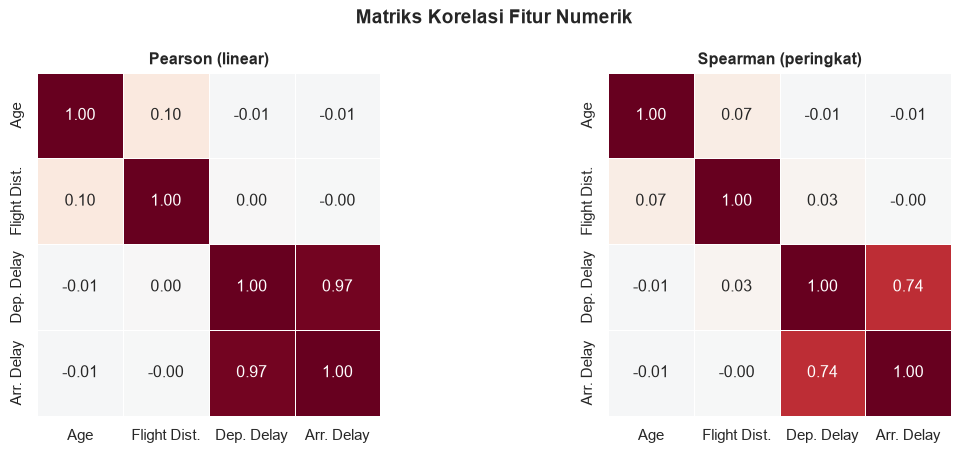

In [23]:
nama_pendek = {"Age": "Age", "Flight Distance": "Flight Dist.",
               "Departure Delay in Minutes": "Dep. Delay", "Arrival Delay in Minutes": "Arr. Delay"}
korr_pearson = df[numeric_cols].corr(method="pearson").rename(index=nama_pendek, columns=nama_pendek)
korr_spearman = df[numeric_cols].corr(method="spearman").rename(index=nama_pendek, columns=nama_pendek)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, m, judul in zip(axes, [korr_pearson, korr_spearman], ["Pearson (linear)", "Spearman (peringkat)"]):
    sns.heatmap(m, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
                linewidths=.5, cbar=False, ax=ax)
    ax.set_title(judul, fontweight="bold")
plt.suptitle("Matriks Korelasi Fitur Numerik", fontweight="bold")
plt.tight_layout()
plt.show()

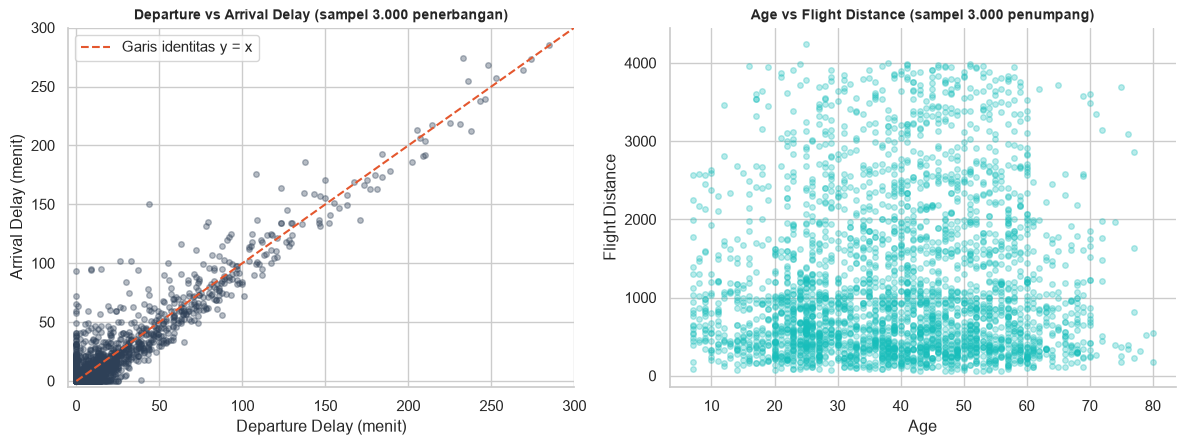

In [24]:
sampel = df.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(sampel[kol_dep], sampel[kol_arr], alpha=.35, s=16, color=C_MAIN)
axes[0].plot([0, 300], [0, 300], color=C_NEG, ls="--", label="Garis identitas y = x")
axes[0].set(xlim=(-5, 300), ylim=(-5, 300), xlabel="Departure Delay (menit)", ylabel="Arrival Delay (menit)")
axes[0].set_title("Departure vs Arrival Delay (sampel 3.000 penerbangan)", fontweight="bold", fontsize=10)
axes[0].legend()

axes[1].scatter(sampel["Age"], sampel["Flight Distance"], alpha=.3, s=16, color=C_POS)
axes[1].set(xlabel="Age", ylabel="Flight Distance")
axes[1].set_title("Age vs Flight Distance (sampel 3.000 penumpang)", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.show()

### ⚠️ Catatan penting tentang korelasi
1. **Korelasi bukan kausalitas.** Korelasi Departure–Arrival Delay yang sangat tinggi (**+0,97**) mencerminkan propagasi keterlambatan: pesawat yang berangkat telat cenderung tiba telat. Keduanya hampir redundan → pertimbangkan **multikolinearitas** pada model linear.
2. `Age` dan `Flight Distance` hanya berkorelasi lemah (**0,10**); tidak ada hubungan linear berarti antara usia dan jarak tempuh.
3. Korelasi hanya untuk pasangan numerik. Pengaruh variabel kategorikal dan rating terhadap kepuasan perlu alat lain (7.2–7.4).

## 7.2 Numerical vs categorical
### a) Jarak penerbangan menurut kelas kabin

Class,count,mean,median,std
Eco,"46,745",743.44,599.00,549.42
Eco Plus,"7,494",747.13,589.00,579.86
Business,"49,665","1,675.98","1,589.00","1,136.61"


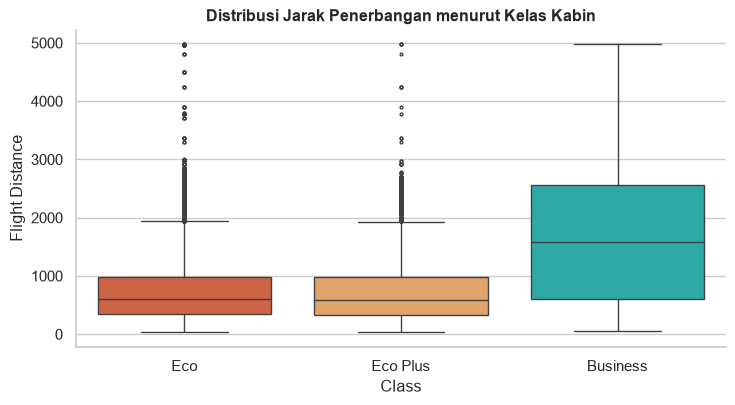

In [25]:
jarak_kelas = df.groupby("Class")["Flight Distance"].agg(["count", "mean", "median", "std"]).reindex(CLASS_ORDER)
jarak_kelas.index.name = "Class"
display(gaya_tabel(jarak_kelas.reset_index()).format(precision=2, thousands=","))

plt.figure(figsize=(7.5, 4.2))
sns.boxplot(data=df, x="Class", y="Flight Distance", order=CLASS_ORDER, hue="Class",
            palette=PAL_CLASS, legend=False, fliersize=2)
plt.title("Distribusi Jarak Penerbangan menurut Kelas Kabin", fontweight="bold")
plt.tight_layout()
plt.show()

### b) Usia penumpang menurut status kepuasan
Dibandingkan dengan uji **Mann–Whitney U**. Nilai `P(Age puas > Age tidak puas)` (*common-language effect size*) menunjukkan seberapa sering penumpang puas lebih tua; nilai 0,50 berarti tidak ada perbedaan.

satisfaction,count,mean,median,std
neutral or dissatisfied,"58,879",37.57,36.00,16.46
satisfied,"45,025",41.75,43.00,12.77


Mann-Whitney U: p-value = 0.000e+00 | P(Age puas > Age tidak puas) = 0.586


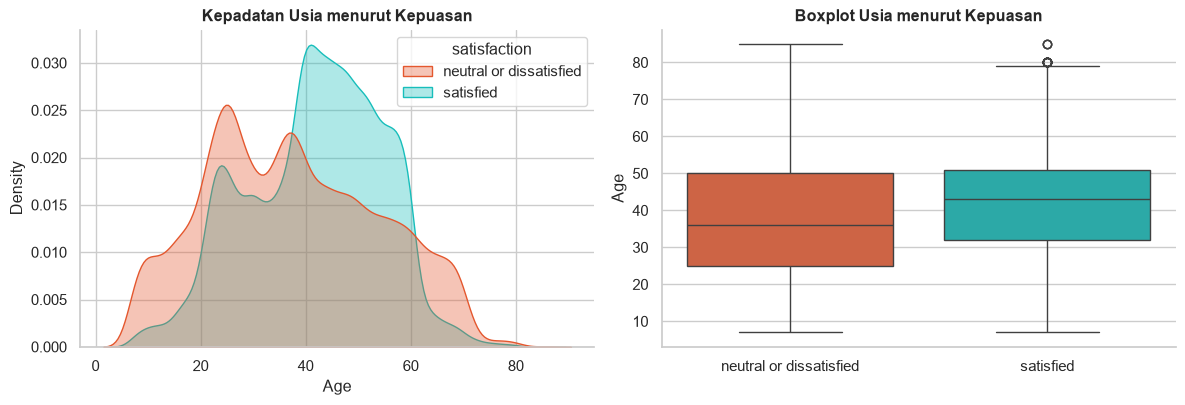

In [26]:
umur_grup = df.groupby("satisfaction")["Age"].agg(["count", "mean", "median", "std"]).reindex(SAT_ORDER)
umur_grup.index.name = "satisfaction"
display(gaya_tabel(umur_grup.reset_index()).format(precision=2, thousands=","))

a_puas = df.loc[df["satisfaction"] == "satisfied", "Age"]
a_tidak = df.loc[df["satisfaction"] != "satisfied", "Age"]
u, p = stats.mannwhitneyu(a_puas, a_tidak, alternative="two-sided")
cles = u / (len(a_puas) * len(a_tidak))
print(f"Mann-Whitney U: p-value = {p:.3e} | P(Age puas > Age tidak puas) = {cles:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.kdeplot(data=df, x="Age", hue="satisfaction", hue_order=SAT_ORDER, palette=PAL_SAT,
            common_norm=False, fill=True, alpha=.35, ax=axes[0])
axes[0].set_title("Kepadatan Usia menurut Kepuasan", fontweight="bold")
sns.boxplot(data=df, x="satisfaction", y="Age", order=SAT_ORDER, hue="satisfaction",
            palette=PAL_SAT, legend=False, ax=axes[1])
axes[1].set_title("Boxplot Usia menurut Kepuasan", fontweight="bold")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

### 🔎 Interpretasi
- **Kelas vs jarak:** penumpang `Business` terbang jauh lebih jauh (rata-rata 1.676; median 1.589) dibanding `Eco` (743; median 599) dan `Eco Plus` (747; median 589). Jarak penerbangan adalah **proksi kelas kabin** — fakta ini penting untuk Langkah 9.3.
- **Usia vs kepuasan:** penumpang puas rata-rata lebih tua (41,75 vs 37,57 tahun; median 43 vs 36) dan sebarannya lebih sempit. Perbedaannya nyata secara statistik (lihat *p-value*); besar efeknya dibaca dari `P(Age puas > Age tidak puas)` — semakin jauh dari 0,50, semakin besar perbedaannya. Sebaran kedua kelompok masih saling tumpang tindih, sehingga usia bukan penentu tunggal.

## 7.3 Categorical vs categorical
Persentase kepuasan **bersyarat** pada setiap kategori. Uji **χ² independensi** dan **Cramér's V** (0 = tidak ada asosiasi, 1 = asosiasi sempurna) dipakai untuk membandingkan kekuatan asosiasi antar variabel.

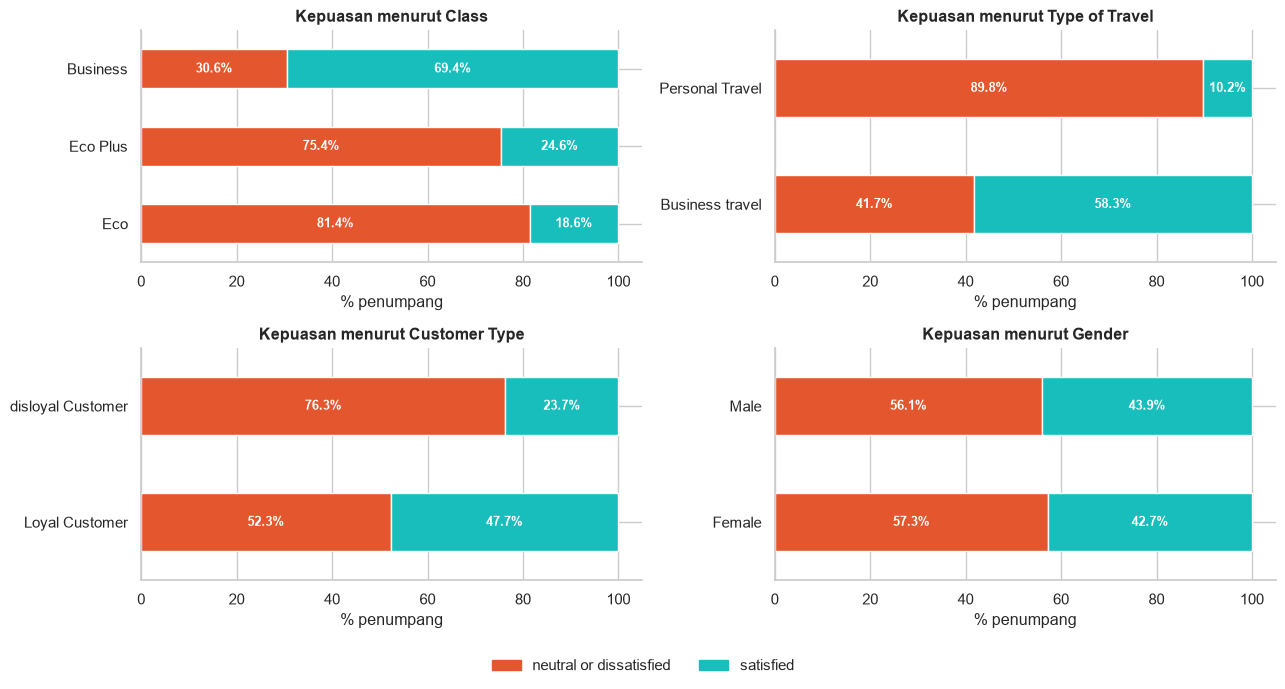

In [27]:
kat_vs_target = ["Class", "Type of Travel", "Customer Type", "Gender"]

fig, axes = plt.subplots(2, 2, figsize=(13, 6.8))
for ax, col in zip(axes.ravel(), kat_vs_target):
    ct = pd.crosstab(df[col], df["satisfaction"], normalize="index")[SAT_ORDER] * 100
    if col == "Class":
        ct = ct.reindex(CLASS_ORDER)
    ct.plot(kind="barh", stacked=True, color=[C_NEG, C_POS], edgecolor="white", ax=ax, legend=False)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f%%", label_type="center", color="white", fontweight="bold", fontsize=9)
    ax.set_title(f"Kepuasan menurut {col}", fontweight="bold")
    ax.set_xlabel("% penumpang")
    ax.set_ylabel("")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (C_NEG, C_POS)]
fig.legend(handles, SAT_ORDER, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

In [28]:
def uji_asosiasi(x, y):
    """Uji chi-kuadrat independensi + Cramer's V untuk dua variabel kategorikal."""
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(ct, correction=False)
    n = ct.values.sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    return chi2, dof, p, v


def kekuatan(v):
    return "sangat lemah" if v < 0.1 else "lemah" if v < 0.3 else "sedang" if v < 0.5 else "kuat"


baris = []
for col in ["Class", "Type of Travel", "Customer Type", "Gender"]:
    chi2, dof, p, v = uji_asosiasi(df[col], df["satisfaction"])
    baris.append({"variabel": col, "chi2": chi2, "dof": dof, "p-value": p, "Cramér's V": v, "kekuatan": kekuatan(v)})
tabel_asosiasi = pd.DataFrame(baris).sort_values("Cramér's V", ascending=False)
display(
    gaya_tabel(tabel_asosiasi)
    .format({"chi2": "{:,.1f}", "p-value": "{:.2e}", "Cramér's V": "{:.3f}"})
    .bar(subset=["Cramér's V"], color=BAR_TEAL, vmin=0, vmax=1)
)

variabel,chi2,dof,p-value,Cramér's V,kekuatan
Class,"26,471.9",2,0.00e+00,0.505,kuat
Type of Travel,"20,947.2",1,0.00e+00,0.449,sedang
Customer Type,"3,658.3",1,0.00e+00,0.188,lemah
Gender,15.5,1,8.28e-05,0.012,sangat lemah


### 🔎 Interpretasi
- **Class:** `Business` **69,4%** puas, `Eco Plus` 24,6%, `Eco` 18,6% → asosiasi kuat (lihat Cramér's V).
- **Type of Travel:** perjalanan bisnis **58,3%** puas vs perjalanan personal hanya **10,2%** → asosiasi kuat (lihat Cramér's V).
- `Customer Type` dan `Gender` juga diuji; urutan kekuatan asosiasi seluruh variabel ditampilkan pada tabel Cramér's V di atas. Dengan 100 ribu lebih baris, *p-value* hampir selalu sangat kecil, sehingga **ukuran efek (Cramér's V) lebih informatif daripada p-value**.

## 7.4 Rating layanan vs kepuasan (Spearman)
Korelasi peringkat antara tiap rating (0–5) dan target biner. Karena nilai `0` bercampur dengan skala 1–5 pada kolom yang sama, korelasi ini hanya gambaran awal; Langkah 9.2 membahas sinyal nilai 0 secara khusus.

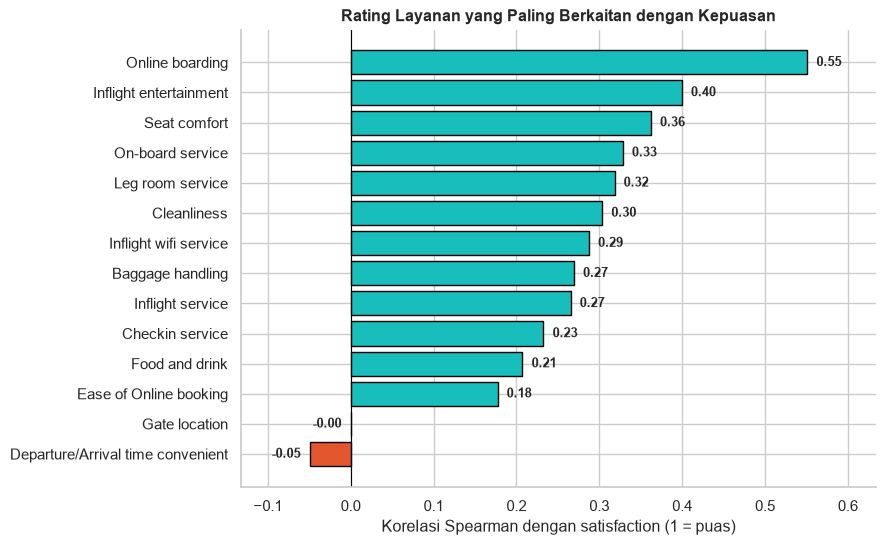

🔎 Hasil otomatis
Tiga rating dengan asosiasi terkuat : Online boarding (0.55), Inflight entertainment (0.40), Seat comfort (0.36)
Tiga rating dengan asosiasi terlemah: Departure/Arrival time convenient (-0.05), Gate location (-0.00), Ease of Online booking (0.18)


In [29]:
rho = pd.Series({c: stats.spearmanr(df[c], sat_bin)[0] for c in rating_cols}).sort_values()

plt.figure(figsize=(9, 5.6))
plt.barh(rho.index, rho.values, color=[C_POS if v >= 0 else C_NEG for v in rho.values], edgecolor="black")
rentang_rho = max(abs(rho.min()), abs(rho.max()))
for i, v in enumerate(rho.values):
    plt.text(v + np.sign(v if v != 0 else 1) * rentang_rho * 0.02, i, f"{v:.2f}", va="center",
             ha="left" if v >= 0 else "right", fontsize=9, fontweight="bold")
plt.xlim(min(rho.min(), 0) - rentang_rho * 0.15, max(rho.max(), 0) + rentang_rho * 0.15)
plt.axvline(0, color="black", lw=.8)
plt.xlabel("Korelasi Spearman dengan satisfaction (1 = puas)")
plt.title("Rating Layanan yang Paling Berkaitan dengan Kepuasan", fontweight="bold")
plt.tight_layout()
plt.show()

print("🔎 Hasil otomatis")
print("Tiga rating dengan asosiasi terkuat :", ", ".join(f"{k} ({v:.2f})" for k, v in rho.tail(3)[::-1].items()))
print("Tiga rating dengan asosiasi terlemah:", ", ".join(f"{k} ({v:.2f})" for k, v in rho.head(3).items()))

> 📌 **Ringkasan Bagian 2.** Kepuasan sangat dipengaruhi oleh **kelas kabin** dan **tujuan perjalanan**; usia berpengaruh sedang; jarak penerbangan terkait erat dengan kelas. Variabel *delay* berkorelasi sangat kuat satu sama lain (0,97) → berpotensi redundan. Hubungan rating–kepuasan sudah terlihat, namun perlu analisis nilai `0` (Bagian 3).

---
# BAGIAN 3 — DETEKSI PENCILAN, PEMERIKSAAN KUALITAS & ANOMALI
**Penanggung Jawab: Surakhbil Al Hasan (NRP 5027261070)**

# 8. Outlier detection

Pencilan (*outlier*) adalah observasi yang jauh dari mayoritas data. Sumbernya bisa berupa:
1. kasus ekstrem yang **sah** secara operasional (mis. keterlambatan berjam-jam karena cuaca),
2. kesalahan pengukuran, atau
3. kesalahan entri data.

Menemukan pencilan **tidak otomatis berarti data harus dihapus**.

## 8.1 Boxplots

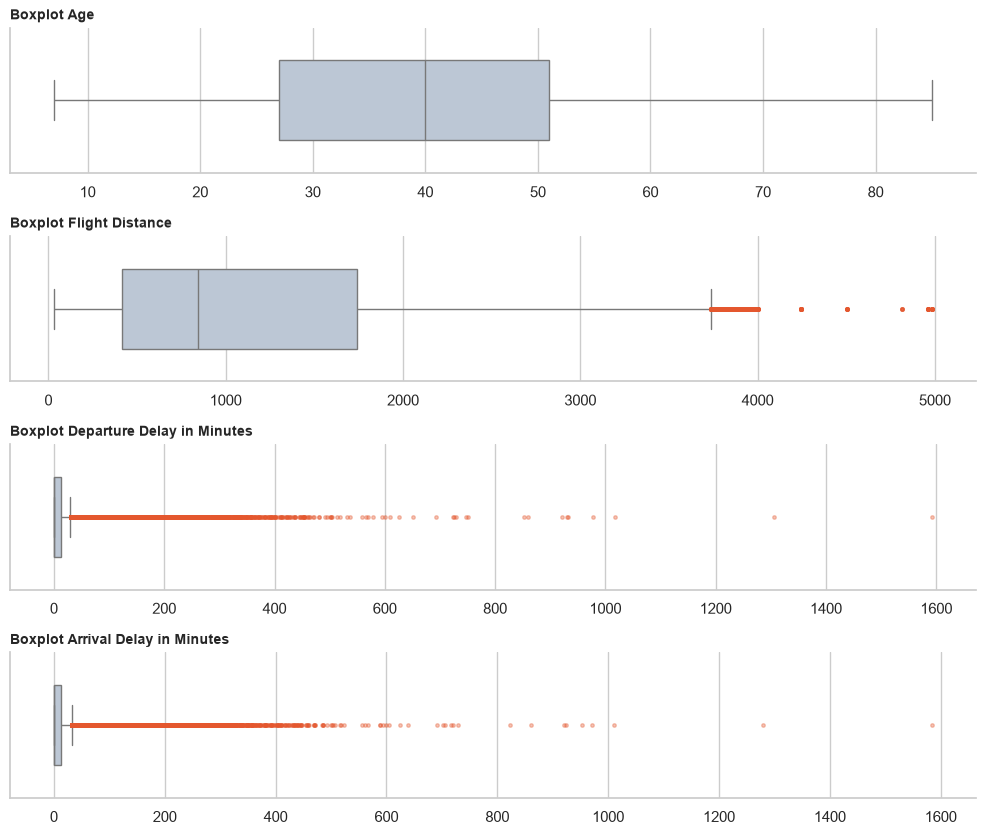

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax, color="#b8c7d9", width=.55,
                flierprops=dict(marker="o", markersize=2.5, alpha=.35,
                                markerfacecolor=C_NEG, markeredgecolor=C_NEG))
    ax.set_xlabel("")
    ax.set_title(f"Boxplot {col}", fontweight="bold", fontsize=10, loc="left")
plt.tight_layout()
plt.show()

## 8.2 IQR method

$$\text{IQR} = Q_3 - Q_1$$

Aturan Tukey menandai nilai sebagai pencilan bila

$$x < Q_1 - 1{,}5\,\text{IQR} \quad \text{atau} \quad x > Q_3 + 1{,}5\,\text{IQR}$$

In [31]:
def detect_iqr_outliers(series, k=1.5):
    """Ringkasan pencilan berdasarkan aturan IQR Tukey (batas = Q1 - k*IQR dan Q3 + k*IQR)."""
    bersih = series.dropna()
    q1, q3 = bersih.quantile(.25), bersih.quantile(.75)
    iqr = q3 - q1
    bawah, atas = q1 - k * iqr, q3 + k * iqr
    mask = (series < bawah) | (series > atas)
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "batas_bawah": bawah, "batas_atas": atas,
            "jumlah_pencilan": int(mask.sum()), "pencilan (%)": mask.mean() * 100}


tabel_iqr = pd.DataFrame({c: detect_iqr_outliers(df[c]) for c in numeric_cols}).T
tabel_iqr.index.name = "variabel"
display(
    gaya_tabel(tabel_iqr.reset_index())
    .format(precision=2, thousands=",")
    .format({"jumlah_pencilan": "{:,.0f}"}, subset=["jumlah_pencilan"])
    .background_gradient(subset=["pencilan (%)"], cmap="OrRd")
)

variabel,Q1,Q3,IQR,batas_bawah,batas_atas,jumlah_pencilan,pencilan (%)
Age,27.00,51.00,24.00,-9.00,87.00,0,0.00
Flight Distance,414.00,"1,743.00","1,329.00","-1,579.50","3,736.50","2,291",2.20
Departure Delay in Minutes,0.00,12.00,12.00,-18.00,30.00,"14,529",13.98
Arrival Delay in Minutes,0.00,13.00,13.00,-19.50,32.50,"13,954",13.43


In [32]:
def get_iqr_outlier_rows(dataframe, column, k=1.5):
    s = dataframe[column]
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    return dataframe[(s < q1 - k * iqr) | (s > q3 + k * iqr)]


print("Contoh 5 baris pencilan pada Flight Distance:")
display(get_iqr_outlier_rows(df, "Flight Distance").head())

Contoh 5 baris pencilan pada Flight Distance:


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
80,73302,Male,Loyal Customer,26,Business travel,Business,3960,1,1,1,1,4,4,4,4,4,2,5,4,4,4,45,48.00,satisfied
173,101275,Male,Loyal Customer,52,Business travel,Business,3747,5,5,5,5,2,4,5,4,4,4,4,5,4,5,24,20.00,satisfied
201,66800,Female,Loyal Customer,43,Business travel,Business,3854,5,5,5,5,5,4,4,5,5,5,5,5,5,3,0,0.00,satisfied
215,23328,Female,Loyal Customer,38,Business travel,Business,3753,2,2,2,2,1,1,5,4,4,4,4,4,4,1,0,0.00,satisfied
379,85109,Male,Loyal Customer,46,Business travel,Business,3995,4,4,4,4,3,4,4,5,5,5,5,5,5,4,0,0.00,satisfied


### ⚠️ Keterbatasan IQR pada data *zero-inflated*
Pada `Departure Delay` dan `Arrival Delay`, aturan IQR menandai **±13–14% baris** sebagai pencilan. Penyebabnya: lebih dari separuh nilai adalah **0**, sehingga $Q_1 = 0$ dan $\text{IQR}$ sangat kecil (12–13 menit). Akibatnya, keterlambatan > 30 menit langsung dianggap pencilan, padahal keterlambatan 1–3 jam adalah kejadian operasional yang nyata. Menghapus 14% baris ini justru merusak analisis.

Tabel berikut memperjelas sifat distribusinya.

variabel,% bernilai 0,median (P50),P75,P90,P95,P99,maks
Departure Delay in Minutes,56.46,0.00,12.00,44.00,78.00,181.97,"1,592.00"
Arrival Delay in Minutes,56.14,0.00,13.00,44.00,79.00,184.00,"1,584.00"


variabel (hanya delay > 0),Q1,Q3,IQR,batas_bawah,batas_atas,jumlah_pencilan,pencilan (%)
Departure Delay in Minutes,6.00,40.00,34.00,-45.00,91.00,"4,099.00",9.06
Arrival Delay in Minutes,6.00,40.00,34.00,-45.00,91.00,"4,174.00",9.19


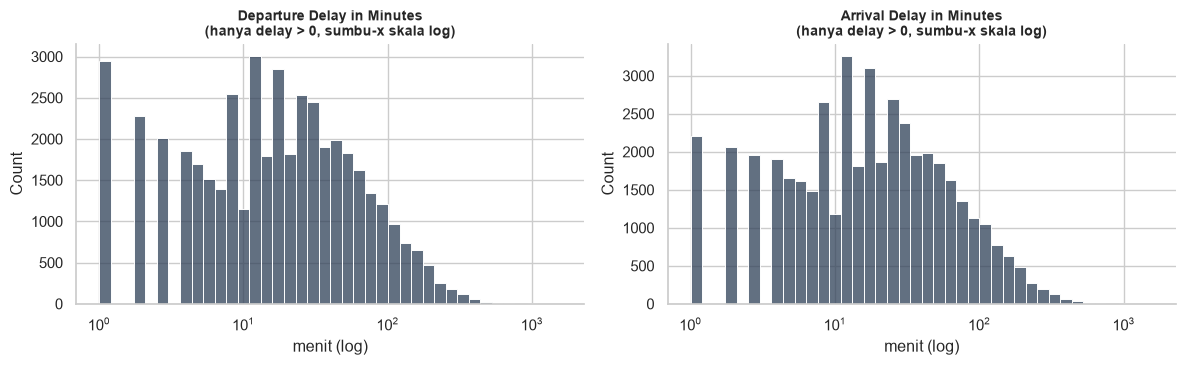

In [33]:
delay_cols = [kol_dep, kol_arr]

profil_delay = pd.DataFrame({
    c: {
        "% bernilai 0": (df[c].dropna() == 0).mean() * 100,
        "median (P50)": df[c].quantile(.50), "P75": df[c].quantile(.75), "P90": df[c].quantile(.90),
        "P95": df[c].quantile(.95), "P99": df[c].quantile(.99), "maks": df[c].max(),
    } for c in delay_cols
}).T
profil_delay.index.name = "variabel"
display(gaya_tabel(profil_delay.reset_index()).format(precision=2, thousands=","))

# IQR hanya pada penerbangan yang benar-benar terlambat (delay > 0)
tabel_iqr_pos = pd.DataFrame({c: detect_iqr_outliers(df.loc[df[c] > 0, c]) for c in delay_cols}).T
tabel_iqr_pos.index.name = "variabel (hanya delay > 0)"
display(gaya_tabel(tabel_iqr_pos.reset_index()).format(precision=2, thousands=","))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, c in zip(axes, delay_cols):
    sns.histplot(df.loc[df[c] > 0, c], bins=40, log_scale=True, color=C_MAIN, edgecolor="white", ax=ax)
    ax.set_title(f"{c}\n(hanya delay > 0, sumbu-x skala log)", fontweight="bold", fontsize=10)
    ax.set_xlabel("menit (log)")
plt.tight_layout()
plt.show()

## 8.3 Z-score method

$$z = \frac{x-\mu}{\sigma}, \qquad \text{pencilan bila } |z| > 3$$

Metode ini mengasumsikan data mendekati normal dan **sensitif** terhadap nilai ekstrem, karena mean dan standar deviasi ikut terdistorsi oleh pencilan itu sendiri.

In [34]:
def zscore_outliers(series, threshold=3):
    """Mengembalikan mask boolean: True bila |z| > threshold (NaN dianggap bukan pencilan)."""
    bersih = series.dropna()
    z = (series - bersih.mean()) / bersih.std()
    return z.abs() > threshold


baris = []
for c in numeric_cols:
    m_iqr = (df[c] < detect_iqr_outliers(df[c])["batas_bawah"]) | (df[c] > detect_iqr_outliers(df[c])["batas_atas"])
    m_z = zscore_outliers(df[c])
    m_zlog = zscore_outliers(np.log1p(df[c]))
    baris.append({"variabel": c, "IQR (1,5)": int(m_iqr.sum()), "IQR (%)": m_iqr.mean() * 100,
                  "Z-score |z|>3": int(m_z.sum()), "Z-score (%)": m_z.mean() * 100,
                  "Z-score pada log1p(x)": int(m_zlog.sum())})
perbandingan = pd.DataFrame(baris)
display(
    gaya_tabel(perbandingan)
    .format({"IQR (1,5)": "{:,}", "Z-score |z|>3": "{:,}", "Z-score pada log1p(x)": "{:,}",
             "IQR (%)": "{:.2f}%", "Z-score (%)": "{:.2f}%"})
)

mask_fd = zscore_outliers(df["Flight Distance"])
print(f"\nPencilan Flight Distance (|z| > 3): {mask_fd.sum():,} baris ({mask_fd.mean() * 100:.2f}%)")
display(df[mask_fd].head(3))

variabel,"IQR (1,5)",IQR (%),Z-score |z|>3,Z-score (%),Z-score pada log1p(x)
Age,0,0.00%,17,0.02%,"1,202"
Flight Distance,"2,291",2.20%,58,0.06%,8
Departure Delay in Minutes,"14,529",13.98%,"2,222",2.14%,54
Arrival Delay in Minutes,"13,954",13.43%,"2,225",2.14%,37



Pencilan Flight Distance (|z| > 3): 58 baris (0.06%)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
994,59271,Female,Loyal Customer,26,Business travel,Business,4243,2,2,2,2,4,4,4,3,5,4,4,4,5,4,26,0.00,satisfied
2401,59270,Female,Loyal Customer,25,Personal Travel,Eco,4963,2,5,2,4,2,5,2,5,3,4,4,2,3,2,0,0.00,neutral or dissatisfied
2847,31870,Female,Loyal Customer,63,Personal Travel,Business,4983,0,5,0,2,0,5,1,3,2,4,3,1,5,1,3,0.00,satisfied


### 🔎 Interpretasi & keputusan penanganan

| Variabel | Temuan | Keputusan |
|---|---|---|
| `Age` | 0 pencilan menurut IQR (batas −9 s.d. 87; rentang data 7–85) | Tidak ada tindakan |
| `Flight Distance` | 2.291 baris (2,20%) menurut IQR, hanya 58 baris (0,06%) menurut z-score; contoh pencilan adalah penerbangan jarak jauh kelas Business | **Pertahankan** — penerbangan jarak jauh yang sah, bukan data rusak |
| `Departure Delay` | 14.529 baris (13,98%) menurut IQR, karena distribusi zero-inflated | **Jangan dihapus**; gunakan `log1p` dan/atau fitur biner `delayed_above_15m` |
| `Arrival Delay` | 13.954 baris (13,43%) menurut IQR | Sama seperti di atas |

Metode z-score menandai jauh lebih sedikit baris daripada IQR (batasnya mengikuti mean dan standar deviasi yang ikut membesar akibat ekor panjang), tetapi keduanya tidak sepenuhnya cocok untuk data *zero-inflated*. Setelah transformasi `log1p`, jumlah pencilan z-score ikut berubah (lihat kolom terakhir tabel), menunjukkan bahwa status "pencilan" bergantung pada skala pengukuran.

> 📌 **Prinsip:** tandai (*flag*) pencilan, selidiki penyebabnya, lalu putuskan. Pencilan operasional yang sah sebaiknya **ditransformasi, bukan dibuang**.

# 9. Data-quality checks beyond missing values and outliers

Selain nilai hilang dan pencilan, kualitas data juga diperiksa dari empat sisi:
1. **Integritas**: duplikasi baris dan identifier,
2. **Validitas**: batas kewajaran nilai dan konsistensi label,
3. **Makna nilai khusus**: rating `0`,
4. **Konfounding**: apakah korelasi jarak–kepuasan menyesatkan?

## 9.1 Integritas & validitas

In [35]:
sat_bin = (df["satisfaction"] == "satisfied").astype(int)   # diulang agar bagian ini mandiri

pemeriksaan = [
    ("Baris duplikat penuh", int(df.duplicated().sum()), df.duplicated().sum() == 0),
    ("Duplikasi kolom id", int(df["id"].duplicated().sum()), df["id"].duplicated().sum() == 0),
    ("Age di luar 0–120", int(((df["Age"] < 0) | (df["Age"] > 120)).sum()), df["Age"].between(0, 120).all()),
    ("Flight Distance <= 0", int((df["Flight Distance"] <= 0).sum()), (df["Flight Distance"] > 0).all()),
    ("Delay bernilai negatif", int((df[delay_cols] < 0).sum().sum()), (df[delay_cols].dropna() >= 0).all().all()),
    ("Rating di luar 0–5", int((~df[rating_cols].isin(range(6))).sum().sum()), df[rating_cols].isin(range(6)).all().all()),
    ("Label teks dengan spasi berlebih", int(sum((df[c] != df[c].str.strip()).sum() for c in categorical_cols)),
     all((df[c] == df[c].str.strip()).all() for c in categorical_cols)),
]
hasil_cek = pd.DataFrame(pemeriksaan, columns=["Pemeriksaan", "Jumlah temuan", "lulus"])
hasil_cek["Status"] = np.where(hasil_cek["lulus"], "✅ Lulus", "⚠️ Perlu perhatian")
display(gaya_tabel(hasil_cek.drop(columns="lulus")))

print("Rentang Age              :", df["Age"].min(), "–", df["Age"].max())
print("Rentang Flight Distance  :", df["Flight Distance"].min(), "–", df["Flight Distance"].max())
print(f"Rentang Arrival Delay    : {df[kol_arr].min():.0f} – {df[kol_arr].max():.0f}")

Pemeriksaan,Jumlah temuan,Status
Baris duplikat penuh,0,✅ Lulus
Duplikasi kolom id,0,✅ Lulus
Age di luar 0–120,0,✅ Lulus
Flight Distance <= 0,0,✅ Lulus
Delay bernilai negatif,0,✅ Lulus
Rating di luar 0–5,0,✅ Lulus
Label teks dengan spasi berlebih,0,✅ Lulus


Rentang Age              : 7 – 85
Rentang Flight Distance  : 31 – 4983
Rentang Arrival Delay    : 0 – 1584


In [36]:
# Konsistensi label kategori: bandingkan label mentah vs. setelah dinormalisasi
baris = []
for col in categorical_cols:
    mentah = sorted(df[col].unique())
    norm = sorted({str(x).strip().lower() for x in mentah})
    baris.append({"kolom": col, "label mentah": "  |  ".join(mentah),
                  "jumlah label": len(mentah), "setelah normalisasi": len(norm)})
display(gaya_tabel(pd.DataFrame(baris)))

kolom,label mentah,jumlah label,setelah normalisasi
Gender,Female | Male,2,2
Customer Type,Loyal Customer | disloyal Customer,2,2
Type of Travel,Business travel | Personal Travel,2,2
Class,Business | Eco | Eco Plus,3,3
satisfaction,neutral or dissatisfied | satisfied,2,2


### 🔎 Interpretasi 9.1
- **Tidak ada** baris duplikat maupun `id` ganda; setiap baris adalah penumpang unik.
- Rentang nilai wajar: usia 7–85 tahun, jarak 31–4.983, *delay* tidak negatif (maks. 1.584 menit ≈ 26 jam — ekstrem, namun mungkin terjadi pada kasus gangguan operasional berat).
- Label **tidak bermasalah dari sisi jumlah** (tidak ada label ganda akibat huruf besar/kecil), namun **gaya penulisan tidak seragam** (`disloyal Customer`, `Business travel`). Ini masalah kosmetik yang mudah diperbaiki dan berbahaya hanya bila dibiarkan saat *encoding* manual.

## 9.2 Sinyal rating `0`
Pada survei berskala 1–5, nilai `0` sering dikira nilai hilang. Namun deskripsi kolom pada halaman dataset Kaggle menjelaskan bahwa `0` berarti *Not Applicable* (layanan tidak digunakan/tidak berlaku). Kami membuktikannya secara empiris dengan membandingkan **persentase puas saat rating = 0** dengan saat rating = 1–5.

In [37]:
baseline = sat_bin.mean() * 100
rekap = []
for c in rating_cols:
    nol = df[c] == 0
    if nol.sum() > 0:
        rekap.append({
            "Layanan": c, "n rating 0": int(nol.sum()), "% penumpang": nol.mean() * 100,
            "% puas | rating 0": sat_bin[nol].mean() * 100,
            "% puas | rating 1–5": sat_bin[~nol].mean() * 100,
            "catatan": "n sangat kecil (<100), jangan ditafsirkan" if nol.sum() < 100 else "",
        })
rekap_nol = pd.DataFrame(rekap).sort_values("n rating 0", ascending=False)
display(
    gaya_tabel(rekap_nol)
    .format({"n rating 0": "{:,}", "% penumpang": "{:.2f}%", "% puas | rating 0": "{:.1f}%", "% puas | rating 1–5": "{:.1f}%"})
    .bar(subset=["% puas | rating 0"], color=BAR_TEAL, vmin=0, vmax=100)
)
print(f"Baseline kepuasan seluruh penumpang: {baseline:.1f}%")

Layanan,n rating 0,% penumpang,% puas | rating 0,% puas | rating 1–5,catatan
Departure/Arrival time convenient,"5,300",5.10%,47.5%,43.1%,
Ease of Online booking,"4,487",4.32%,66.4%,42.3%,
Inflight wifi service,"3,103",2.99%,99.7%,41.6%,
Online boarding,"2,428",2.34%,55.6%,43.0%,
Leg room service,472,0.45%,35.2%,43.4%,
Food and drink,107,0.10%,46.7%,43.3%,
Inflight entertainment,14,0.01%,0.0%,43.3%,"n sangat kecil (<100), jangan ditafsirkan"
Cleanliness,12,0.01%,0.0%,43.3%,"n sangat kecil (<100), jangan ditafsirkan"
Inflight service,3,0.00%,0.0%,43.3%,"n sangat kecil (<100), jangan ditafsirkan"
On-board service,3,0.00%,0.0%,43.3%,"n sangat kecil (<100), jangan ditafsirkan"


Baseline kepuasan seluruh penumpang: 43.3%


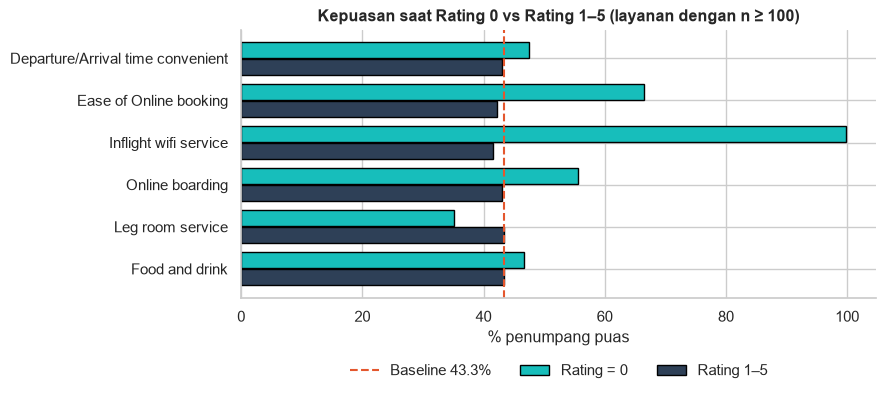

In [38]:
besar = rekap_nol[rekap_nol["n rating 0"] >= 100].sort_values("n rating 0")
y_pos = np.arange(len(besar))

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(y_pos + 0.2, besar["% puas | rating 0"], height=0.38, color=C_POS, edgecolor="black", label="Rating = 0")
ax.barh(y_pos - 0.2, besar["% puas | rating 1–5"], height=0.38, color=C_MAIN, edgecolor="black", label="Rating 1–5")
ax.axvline(baseline, color=C_NEG, ls="--", label=f"Baseline {baseline:.1f}%")
ax.set_yticks(y_pos)
ax.set_yticklabels(besar["Layanan"])
ax.set_xlabel("% penumpang puas")
ax.set_title("Kepuasan saat Rating 0 vs Rating 1–5 (layanan dengan n ≥ 100)", fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

In [39]:
# Banyaknya layanan yang diberi rating 0 oleh satu penumpang vs kepuasan
jumlah_nol = df[rating_cols].eq(0).sum(axis=1).clip(upper=3).map({0: "0", 1: "1", 2: "2", 3: "≥ 3"})
tabel_jml = sat_bin.groupby(jumlah_nol).agg(["size", "mean"]).reindex(["0", "1", "2", "≥ 3"])
tabel_jml.columns = ["jumlah penumpang", "% puas"]
tabel_jml["% puas"] *= 100
tabel_jml.index.name = "banyak layanan bernilai 0"
display(gaya_tabel(tabel_jml.reset_index()).format({"jumlah penumpang": "{:,}", "% puas": "{:.1f}%"}))

banyak layanan bernilai 0,jumlah penumpang,% puas
0,"95,704",42.6%
1,"3,648",33.9%
2,"1,938",37.4%
≥ 3,"2,614",88.2%


### 🔎 Interpretasi 9.2
- Penumpang yang memberi **wifi = 0 (n = 3.103) hampir semuanya puas (99,7%)** — jauh di atas baseline 43,3%. Layanan lain menunjukkan pola yang berbeda-beda: pemesanan online = 0 (n = 4.487) → 66,4% puas; online boarding = 0 (n = 2.428) → 55,6% puas; waktu berangkat/tiba = 0 (n = 5.300) → 47,5% puas; ruang kaki = 0 (n = 472) → 35,2% puas.
- Bila `0` benar-benar nilai terburuk, kepuasan seharusnya rendah. Untuk wifi dan pemesanan online yang terjadi justru sebaliknya, sehingga `0` lebih tepat dibaca sebagai **"layanan tidak digunakan / tidak berlaku"** (sesuai deskripsi Kaggle) daripada penilaian buruk atau data hilang. Karena pola tiap layanan berbeda, nilai 0 membawa informasi yang spesifik per layanan.
- Beberapa layanan hanya punya segelintir nilai 0 (mis. `Gate location` hanya 1 baris dengan 100% puas): angka seperti itu **tidak boleh ditafsirkan** karena n terlalu kecil.
- **Implikasi:** nilai 0 membawa sinyal prediktif dan **tidak boleh diimputasi** dengan median/mean. Pertahankan, dan bentuk fitur indikator (Langkah 11–12). Ini adalah **asosiasi**, bukan bukti sebab-akibat: penumpang yang tidak memakai wifi bisa saja berbeda dalam hal kelas atau tujuan perjalanan.

## 9.3 Confounding jarak penerbangan: efek jarak berbeda antar kelas
Secara agregat, jarak penerbangan tampak berkorelasi **positif** dengan kepuasan. Karena jarak berkaitan erat dengan kelas kabin (Langkah 7.2) dan kelas sangat memengaruhi kepuasan, kami menguji apakah hubungan itu tetap sama **di dalam tiap kelas**.

kelompok,korelasi Flight Distance–kepuasan
Agregat (semua kelas),+0.299
Kelas Eco,-0.047
Kelas Eco Plus,-0.061
Kelas Business,+0.148


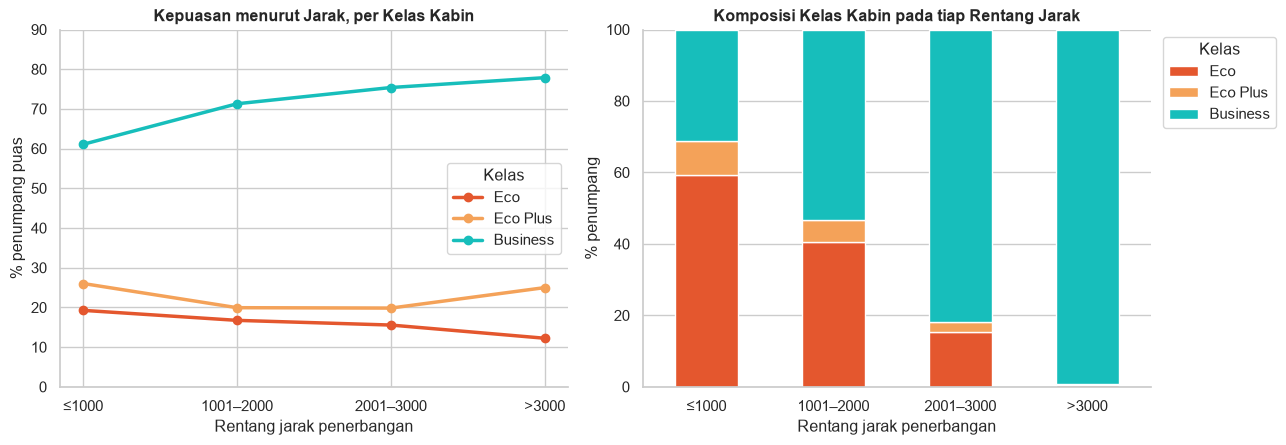

Jumlah penumpang per sel (pastikan tidak terlalu kecil):


Class,Eco,Eco Plus,Business
Flight Distance,,,
≤1000,35606,5735,18724
1001–2000,9086,1374,11966
2001–3000,2004,373,10771
>3000,49,12,8204


In [40]:
jarak_grup = pd.cut(df["Flight Distance"], bins=[0, 1000, 2000, 3000, np.inf],
                    labels=["≤1000", "1001–2000", "2001–3000", ">3000"], include_lowest=True)

korr_agregat = df["Flight Distance"].corr(sat_bin)
korr_per_kelas = pd.Series({k: df.loc[df["Class"] == k, "Flight Distance"].corr(sat_bin[df["Class"] == k])
                            for k in CLASS_ORDER})
tabel_korr = pd.DataFrame({"kelompok": ["Agregat (semua kelas)"] + [f"Kelas {k}" for k in CLASS_ORDER],
                           "korelasi Flight Distance–kepuasan": [korr_agregat] + list(korr_per_kelas.values)})
display(gaya_tabel(tabel_korr).format({"korelasi Flight Distance–kepuasan": "{:+.3f}"}))

pct_puas = (sat_bin.groupby([jarak_grup, df["Class"]], observed=True).mean().unstack() * 100)[CLASS_ORDER]
n_sel = pd.crosstab(jarak_grup, df["Class"])[CLASS_ORDER]
komposisi = pd.crosstab(jarak_grup, df["Class"], normalize="index")[CLASS_ORDER] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for k in CLASS_ORDER:
    axes[0].plot(pct_puas.index.astype(str), pct_puas[k], marker="o", lw=2.5, color=PAL_CLASS[k], label=k)
axes[0].set(ylim=(0, 90), xlabel="Rentang jarak penerbangan", ylabel="% penumpang puas")
axes[0].set_title("Kepuasan menurut Jarak, per Kelas Kabin", fontweight="bold")
axes[0].legend(title="Kelas")

komposisi.plot(kind="bar", stacked=True, color=[PAL_CLASS[k] for k in CLASS_ORDER], edgecolor="white",
               ax=axes[1], rot=0)
axes[1].set(xlabel="Rentang jarak penerbangan", ylabel="% penumpang", ylim=(0, 100))
axes[1].set_title("Komposisi Kelas Kabin pada tiap Rentang Jarak", fontweight="bold")
axes[1].legend(title="Kelas", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print("Jumlah penumpang per sel (pastikan tidak terlalu kecil):")
display(n_sel)

### 🔎 Interpretasi 9.3
- Korelasi **agregat** jarak–kepuasan bertanda positif, tetapi tandanya **tidak sama di setiap kelas** (lihat tabel korelasi per kelas).
- Dari grafik: pada **Business**, kepuasan cenderung naik seiring jarak (kira-kira 61% → 78%); pada **Eco**, kepuasan justru **turun** (kira-kira 19% → 12%); pada **Eco Plus**, polanya naik-turun tanpa tren jelas (±20–26%).
- Panel kanan menunjukkan penyebabnya: **semakin jauh jarak, semakin besar porsi penumpang Business**. Korelasi positif agregat sebagian merupakan **efek komposisi kelas** (confounding), bukan efek jarak itu sendiri. Pada kelas Eco arah hubungannya bahkan berbalik, yaitu pola yang menyerupai **Simpson's paradox**.
- **Implikasi pemodelan:** jangan menafsirkan jarak sebagai penyebab kepuasan tanpa mengontrol kelas; sertakan **`Class` dan interaksi `Class × Flight Distance`**.

> 📌 **Ringkasan Bagian 3.** Pencilan pada data *delay* adalah **ekor operasional yang sah** sehingga ditransformasi, bukan dihapus. Data bebas duplikat dan rentang nilainya wajar. Rating `0` adalah **sinyal "tidak berlaku"** yang harus dipertahankan, dan efek jarak penerbangan terkonfounding oleh kelas kabin.

---
# BAGIAN 4 — SINTESIS EDA, PRA-PEMROSESAN & PENGAYAAN
**Penanggung Jawab: Nabil Ganendra Isbandi (NRP 5027261122)**

# 10. Build an EDA summary

Seluruh temuan dirangkum dalam empat aspek: **Issue** (masalah), **Observation** (fakta empiris), **Risk** (dampak terhadap pemodelan), dan **Recommended action** (tindakan). Kolom *Prioritas* membantu menentukan urutan pengerjaan dan *Rujukan* menunjuk ke langkah asal temuan.

In [41]:
ringkasan_eda = pd.DataFrame([
    {"No": 1, "Prioritas": "Tinggi", "Rujukan": "Langkah 5",
     "Issue": "Nilai hilang pada Arrival Delay (pola MAR)",
     "Observation": "310 baris (0,30%). Rata-rata Departure Delay pada baris hilang 37,43 menit vs 14,75 menit pada baris lengkap.",
     "Risk": "Sebagian besar algoritma tidak menerima NaN; menghapus baris atau memakai median akan bias karena kehilangan tidak acak.",
     "Recommended action": "Imputasi dengan Departure Delay baris yang sama (MAE 4,97 menit vs 15,18 menit untuk median)."},
    {"No": 2, "Prioritas": "Tinggi", "Rujukan": "Langkah 9.2",
     "Issue": "Rating 0 = sinyal \"tidak berlaku\"",
     "Observation": "Wifi = 0 (n = 3.103) memiliki 99,7% penumpang puas; pola berbeda pada tiap layanan.",
     "Risk": "Mengimputasi 0 dengan median/mean menghapus sinyal prediktif; memperlakukan 0 sebagai skor terburuk menyesatkan model linear.",
     "Recommended action": "Pertahankan nilai 0, tambahkan indikator `*_is_0` dan total layanan bernilai 0."},
    {"No": 3, "Prioritas": "Tinggi", "Rujukan": "Langkah 6, 8",
     "Issue": "Delay bersifat zero-inflated dan sangat menceng",
     "Observation": "Median 0 menit, maks > 1.500 menit; IQR menandai 13,98% (Departure) dan 13,43% (Arrival) sebagai pencilan.",
     "Risk": "Model linear/berbasis jarak terdistorsi ekor panjang; penghapusan pencilan membuang ±14% data sah.",
     "Recommended action": "Transformasi log1p dan fitur biner delayed_above_15m; jangan hapus baris."},
    {"No": 4, "Prioritas": "Tinggi", "Rujukan": "Langkah 7.2, 9.3",
     "Issue": "Confounding Flight Distance oleh Class",
     "Observation": "Jarak berkorelasi positif agregat, tetapi di kelas Eco kepuasan menurun seiring jarak dan porsi Business membesar pada jarak jauh.",
     "Risk": "Model dapat menafsirkan jarak sebagai penyebab kepuasan tanpa mengontrol kelas kabin.",
     "Recommended action": "Sertakan Class dan fitur interaksi Class × log(Flight Distance)."},
    {"No": 5, "Prioritas": "Sedang", "Rujukan": "Langkah 7.1",
     "Issue": "Multikolinearitas Departure vs Arrival Delay",
     "Observation": "Korelasi Pearson 0,97.",
     "Risk": "Koefisien model linear tidak stabil dan sulit ditafsirkan.",
     "Recommended action": "Pilih salah satu atau gunakan regularisasi/model berbasis pohon."},
    {"No": 6, "Prioritas": "Sedang", "Rujukan": "Langkah 4, 9.1",
     "Issue": "Gaya penulisan label tidak seragam",
     "Observation": "`disloyal Customer` vs `Loyal Customer`; `Business travel` vs `Personal Travel`.",
     "Risk": "Encoding manual dapat salah mencocokkan string dan menghasilkan NaN.",
     "Recommended action": "Standarkan teks (strip + title case) dan validasi himpunan label."},
    {"No": 7, "Prioritas": "Sedang", "Rujukan": "Langkah 1, 3",
     "Issue": "Kolom identifier id",
     "Observation": "Unik untuk setiap penumpang (tidak ada duplikasi).",
     "Risk": "Tidak bermakna prediktif; berisiko overfitting bila ikut dilatih.",
     "Recommended action": "Keluarkan id dari matriks fitur."},
    {"No": 8, "Prioritas": "Rendah", "Rujukan": "Langkah 4",
     "Issue": "Keseimbangan target & kelas minoritas",
     "Observation": "Target 56,7% vs 43,3%; Eco Plus hanya 7,2% data.",
     "Risk": "Akurasi saja kurang informatif; estimasi untuk Eco Plus lebih tidak stabil.",
     "Recommended action": "Gunakan stratified split dan metrik F1/ROC-AUC di samping akurasi (baseline akurasi 56,7%)."},
])

display(
    gaya_tabel(ringkasan_eda)
    .set_properties(**{"white-space": "pre-wrap", "vertical-align": "top", "text-align": "left"})
    .set_properties(subset=["Observation", "Risk", "Recommended action"], **{"min-width": "230px"})
)

No,Prioritas,Rujukan,Issue,Observation,Risk,Recommended action
1,Tinggi,Langkah 5,Nilai hilang pada Arrival Delay (pola MAR),"310 baris (0,30%). Rata-rata Departure Delay pada baris hilang 37,43 menit vs 14,75 menit pada baris lengkap.",Sebagian besar algoritma tidak menerima NaN; menghapus baris atau memakai median akan bias karena kehilangan tidak acak.,"Imputasi dengan Departure Delay baris yang sama (MAE 4,97 menit vs 15,18 menit untuk median)."
2,Tinggi,Langkah 9.2,"Rating 0 = sinyal ""tidak berlaku""","Wifi = 0 (n = 3.103) memiliki 99,7% penumpang puas; pola berbeda pada tiap layanan.",Mengimputasi 0 dengan median/mean menghapus sinyal prediktif; memperlakukan 0 sebagai skor terburuk menyesatkan model linear.,"Pertahankan nilai 0, tambahkan indikator `*_is_0` dan total layanan bernilai 0."
3,Tinggi,"Langkah 6, 8",Delay bersifat zero-inflated dan sangat menceng,"Median 0 menit, maks > 1.500 menit; IQR menandai 13,98% (Departure) dan 13,43% (Arrival) sebagai pencilan.",Model linear/berbasis jarak terdistorsi ekor panjang; penghapusan pencilan membuang ±14% data sah.,Transformasi log1p dan fitur biner delayed_above_15m; jangan hapus baris.
4,Tinggi,"Langkah 7.2, 9.3",Confounding Flight Distance oleh Class,"Jarak berkorelasi positif agregat, tetapi di kelas Eco kepuasan menurun seiring jarak dan porsi Business membesar pada jarak jauh.",Model dapat menafsirkan jarak sebagai penyebab kepuasan tanpa mengontrol kelas kabin.,Sertakan Class dan fitur interaksi Class × log(Flight Distance).
5,Sedang,Langkah 7.1,Multikolinearitas Departure vs Arrival Delay,"Korelasi Pearson 0,97.",Koefisien model linear tidak stabil dan sulit ditafsirkan.,Pilih salah satu atau gunakan regularisasi/model berbasis pohon.
6,Sedang,"Langkah 4, 9.1",Gaya penulisan label tidak seragam,`disloyal Customer` vs `Loyal Customer`; `Business travel` vs `Personal Travel`.,Encoding manual dapat salah mencocokkan string dan menghasilkan NaN.,Standarkan teks (strip + title case) dan validasi himpunan label.
7,Sedang,"Langkah 1, 3",Kolom identifier id,Unik untuk setiap penumpang (tidak ada duplikasi).,Tidak bermakna prediktif; berisiko overfitting bila ikut dilatih.,Keluarkan id dari matriks fitur.
8,Rendah,Langkah 4,Keseimbangan target & kelas minoritas,"Target 56,7% vs 43,3%; Eco Plus hanya 7,2% data.",Akurasi saja kurang informatif; estimasi untuk Eco Plus lebih tidak stabil.,"Gunakan stratified split dan metrik F1/ROC-AUC di samping akurasi (baseline akurasi 56,7%)."


# 11. Recommended preprocessing

Berdasarkan temuan EDA, rencana pra-pemrosesan disusun sebagai berikut:

| Langkah | Tindakan | Alasan (rujukan) | Kolom terkait |
|:--:|---|---|---|
| 1 | **Standardisasi label** — `strip()` spasi & *title case* untuk `Gender`, `Customer Type`, `Type of Travel`, `Class`; huruf kecil untuk `satisfaction`. Validasi bahwa label hanya berisi nilai yang diharapkan | Label tidak seragam (Langkah 4, 9.1) | 5 kolom kategorikal |
| 2 | **Imputasi MAR** — isi `Arrival Delay` dengan `Departure Delay` baris yang sama | MAE 4,97 vs 15,18 (Langkah 5) | `Arrival Delay in Minutes` |
| 3 | **Pertahankan rating 0** — buat indikator `*_is_0` untuk layanan dengan nilai 0 yang banyak (≥ 1.000 baris pada data latih) dan fitur `n_zero_ratings` | 0 = sinyal "tidak berlaku" (Langkah 9.2) | 14 rating |
| 4 | **Transformasi delay** — `log1p` dan fitur biner `delayed_above_15m` | Zero-inflated (Langkah 6, 8) | 2 kolom delay |
| 5 | **Encoding kategorikal** — ordinal untuk `Class` (Eco=1, Eco Plus=2, Business=3); biner untuk `Gender`, `Customer Type`, `Type of Travel`, dan target | Menjaga urutan kelas kabin | 5 kolom kategorikal |
| 6 | **Fitur interaksi** — `Class × log1p(Flight Distance)` | Confounding jarak–kelas (Langkah 9.3) | `Class`, `Flight Distance` |
| 7 | **Buang identifier** — hapus `id` dari matriks fitur | Tidak prediktif (Langkah 3) | `id` |

> ⚠️ **Mencegah kebocoran data (*data leakage*).** Pipeline hanya memakai informasi *fitur* (tidak menyentuh target), dan daftar kolom indikator `*_is_0` ditentukan **sekali dari data latih** lalu dipakai ulang untuk data uji. Langkah yang mempelajari statistik dari data (mis. penskalaan, *target encoding*) harus di-*fit* pada data latih saja dan baru diterapkan ke data uji; langkah tersebut sengaja tidak dilakukan pada EDA ini.

# 12. Example preprocessing implementation

Seluruh rekomendasi dikemas dalam **satu fungsi** `preprocess()` agar dapat diterapkan identik pada `train.csv` dan `test.csv` (yang juga diunduh dari Kaggle pada Langkah 1).

In [42]:
def nama_aman(teks):
    """Mengubah nama kolom menjadi huruf kecil bergaris-bawah, mis. 'Inflight wifi service' -> 'inflight_wifi_service'."""
    return re.sub(r"[^0-9a-zA-Z]+", "_", teks).strip("_").lower()


# Kolom indikator rating-0 ditentukan SEKALI dari data latih, lalu dipakai ulang pada data lain
ZERO_COLS = [c for c in rating_cols if (df[c] == 0).sum() >= 1000]
print("Kolom yang mendapat indikator rating-0:", ZERO_COLS)

LABEL_VALID = {
    "Gender": {"Female", "Male"},
    "Customer Type": {"Loyal Customer", "Disloyal Customer"},
    "Type of Travel": {"Business Travel", "Personal Travel"},
    "Class": {"Eco", "Eco Plus", "Business"},
    "satisfaction": {"satisfied", "neutral or dissatisfied"},
}


def preprocess(data, zero_cols=ZERO_COLS):
    out = data.copy()

    # 1) Standardisasi label + validasi himpunan label
    for col in ["Gender", "Customer Type", "Type of Travel", "Class"]:
        out[col] = out[col].astype(str).str.strip().str.title()
    out["satisfaction"] = out["satisfaction"].astype(str).str.strip().str.lower()
    for col, valid in LABEL_VALID.items():
        tak_dikenal = set(out[col].unique()) - valid
        if tak_dikenal:
            raise ValueError(f"Label tak dikenal pada kolom {col}: {tak_dikenal}")

    # 2) Imputasi MAR: Arrival Delay <- Departure Delay (baris yang sama)
    out["Arrival Delay in Minutes"] = out["Arrival Delay in Minutes"].fillna(out["Departure Delay in Minutes"])

    # 3) Pertahankan sinyal rating 0
    out["n_zero_ratings"] = out[rating_cols].eq(0).sum(axis=1)
    for c in zero_cols:
        out[f"{nama_aman(c)}_is_0"] = (out[c] == 0).astype(int)

    # 4) Transformasi variabel delay
    out["dep_delay_log"] = np.log1p(out["Departure Delay in Minutes"])
    out["arr_delay_log"] = np.log1p(out["Arrival Delay in Minutes"])
    out["delayed_above_15m"] = (out["Arrival Delay in Minutes"] > 15).astype(int)

    # 5) Encoding kategorikal
    out["class_encoded"] = out["Class"].map({"Eco": 1, "Eco Plus": 2, "Business": 3})
    out["is_business_travel"] = (out["Type of Travel"] == "Business Travel").astype(int)
    out["is_loyal_customer"] = (out["Customer Type"] == "Loyal Customer").astype(int)
    out["is_male"] = (out["Gender"] == "Male").astype(int)
    out["target_satisfied"] = (out["satisfaction"] == "satisfied").astype(int)

    # 6) Fitur interaksi kelas x jarak
    out["flight_distance_log"] = np.log1p(out["Flight Distance"])
    out["class_x_log_distance"] = out["class_encoded"] * out["flight_distance_log"]

    # 7) Buang identifier
    return out.drop(columns=["id"], errors="ignore")


clean_df = preprocess(df)
clean_test = preprocess(df_test)

print(f"\nTotal nilai hilang setelah pra-pemrosesan -> train: {int(clean_df.isna().sum().sum())} | test: {int(clean_test.isna().sum().sum())}")
print(f"Dimensi data bersih -> train: {clean_df.shape} | test: {clean_test.shape}")
print("Kolom train dan test identik:", list(clean_df.columns) == list(clean_test.columns))
display(clean_df.head(3))

Kolom yang mendapat indikator rating-0: ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Online boarding']

Total nilai hilang setelah pra-pemrosesan -> train: 0 | test: 0
Dimensi data bersih -> train: (103904, 38) | test: (25976, 38)
Kolom train dan test identik: True


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,n_zero_ratings,inflight_wifi_service_is_0,departure_arrival_time_convenient_is_0,ease_of_online_booking_is_0,online_boarding_is_0,dep_delay_log,arr_delay_log,delayed_above_15m,class_encoded,is_business_travel,is_loyal_customer,is_male,target_satisfied,flight_distance_log,class_x_log_distance
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.00,neutral or dissatisfied,0,0,0,0,0,3.26,2.94,1,2,0,1,1,0,6.13,12.27
1,Male,Disloyal Customer,25,Business Travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.00,neutral or dissatisfied,0,0,0,0,0,0.69,1.95,0,3,1,0,1,0,5.46,16.39
2,Female,Loyal Customer,26,Business Travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.00,satisfied,0,0,0,0,0,0.00,0.00,0,3,1,1,0,1,7.04,21.12


In [43]:
# Matriks fitur (X) dan target (y) siap pakai untuk pemodelan
kolom_teks = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]
X = clean_df.drop(columns=kolom_teks + ["target_satisfied"])
y = clean_df["target_satisfied"]

print(f"Matriks fitur X : {X.shape[0]:,} baris x {X.shape[1]} fitur")
print("Semua fitur numerik     :", all(pd.api.types.is_numeric_dtype(X[c]) for c in X.columns))
print("Target tidak ada di X   :", "target_satisfied" not in X.columns)
print("id tidak ada di X       :", "id" not in X.columns)
print(f"\nKeseimbangan target setelah encoding: puas = {y.mean() * 100:.2f}%  |  tidak puas = {(1 - y.mean()) * 100:.2f}%")

fitur_baru = [c for c in X.columns if c not in df.columns]
print(f"\n{len(fitur_baru)} fitur hasil rekayasa:")
print(fitur_baru)

Matriks fitur X : 103,904 baris x 32 fitur
Semua fitur numerik     : True
Target tidak ada di X   : True
id tidak ada di X       : True

Keseimbangan target setelah encoding: puas = 43.33%  |  tidak puas = 56.67%

14 fitur hasil rekayasa:
['n_zero_ratings', 'inflight_wifi_service_is_0', 'departure_arrival_time_convenient_is_0', 'ease_of_online_booking_is_0', 'online_boarding_is_0', 'dep_delay_log', 'arr_delay_log', 'delayed_above_15m', 'class_encoded', 'is_business_travel', 'is_loyal_customer', 'is_male', 'flight_distance_log', 'class_x_log_distance']


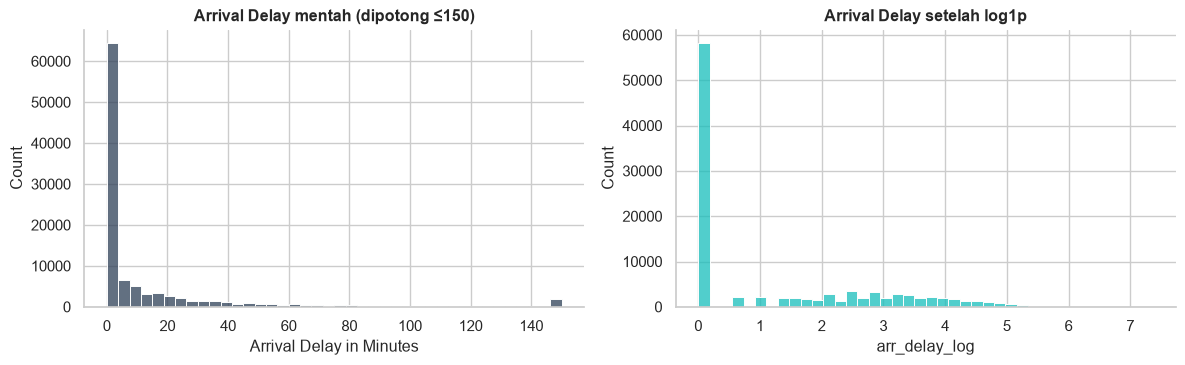

Skewness Arrival Delay: mentah = 6.56 -> log1p = 0.87


In [44]:
# Bukti bahwa imputasi bekerja & hasil transformasi delay lebih simetris
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(clean_df["Arrival Delay in Minutes"].clip(upper=150), bins=40, color=C_MAIN, ax=axes[0])
axes[0].set_title("Arrival Delay mentah (dipotong ≤150)", fontweight="bold")
sns.histplot(clean_df["arr_delay_log"], bins=40, color=C_POS, ax=axes[1])
axes[1].set_title("Arrival Delay setelah log1p", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Skewness Arrival Delay: mentah = {clean_df['Arrival Delay in Minutes'].skew():.2f} -> log1p = {clean_df['arr_delay_log'].skew():.2f}")

# 13. Final EDA checklist

Sebelum masuk ke pemodelan, kami memeriksa daftar berikut. Kolom *Bukti* menunjuk langkah yang menjawabnya; sel di bawah tabel **memverifikasi secara otomatis** hal-hal yang dapat diuji dengan kode.

| ✔ | Pertanyaan | Bukti |
|:--:|---|---|
| ✅ | Apakah kami memahami arti setiap baris (satu penumpang)? | Langkah 1 |
| ✅ | Apakah kami memahami makna setiap variabel? | Kamus data, Langkah 1 |
| ✅ | Apakah tipe teknis sudah diselaraskan dengan tipe analitis? | Langkah 3 |
| ✅ | Mana variabel numerik, kategorikal, rating, identifier? | Langkah 3–4 |
| ✅ | Apakah label kategori konsisten? | Langkah 4, 9.1 → diperbaiki Langkah 12 |
| ✅ | Apakah ada nilai hilang dan berapa persentasenya? | Langkah 5 |
| ✅ | Apakah mekanisme hilang (MCAR vs MAR) diuji? | Langkah 5 |
| ✅ | Apakah ada duplikasi baris atau identifier? | Langkah 9.1 |
| ✅ | Apakah nilai ekstrem rusak atau sah? | Langkah 8 |
| ✅ | Apakah ada makna khusus pada nilai tertentu (rating 0)? | Langkah 9.2 |
| ✅ | Apakah korelasi semu / confounding diperiksa? | Langkah 7.2, 9.3 |
| ✅ | Apakah keseimbangan target dievaluasi? | Langkah 4 |
| ✅ | Apakah setiap keputusan pra-pemrosesan punya justifikasi? | Langkah 10–11 |
| ✅ | Apakah pipeline bebas kebocoran data & dapat dipakai ulang di data uji? | Langkah 11–12 |

In [45]:
audit = [
    ("id unik pada data latih", df["id"].is_unique),
    ("Tidak ada baris duplikat pada data latih", not df.duplicated().any()),
    ("Kamus data mencakup seluruh kolom", list(kamus_data["Variabel"]) == list(df.columns)),
    ("Tidak ada nilai hilang setelah pra-pemrosesan (train)", clean_df.isna().sum().sum() == 0),
    ("Tidak ada nilai hilang setelah pra-pemrosesan (test)", clean_test.isna().sum().sum() == 0),
    ("Jumlah baris tidak berubah setelah pra-pemrosesan", len(clean_df) == len(df) and len(clean_test) == len(df_test)),
    ("Target biner (hanya 0 dan 1)", set(y.unique()) <= {0, 1}),
    ("Semua fitur X numerik", all(pd.api.types.is_numeric_dtype(X[c]) for c in X.columns)),
    ("Target & id tidak bocor ke fitur", not ({"target_satisfied", "satisfaction", "id"} & set(X.columns))),
    ("Kolom data latih dan uji identik", list(clean_df.columns) == list(clean_test.columns)),
    ("Rating 0 masih dipertahankan (tidak diimputasi)", int((clean_df[rating_cols] == 0).sum().sum()) == int((df[rating_cols] == 0).sum().sum())),
]
hasil_audit = pd.DataFrame(audit, columns=["Pemeriksaan otomatis", "lulus"])
hasil_audit["Status"] = np.where(hasil_audit["lulus"], "✅ PASS", "❌ FAIL")
display(gaya_tabel(hasil_audit.drop(columns="lulus")))

assert hasil_audit["lulus"].all(), "Ada pemeriksaan yang gagal, periksa tabel di atas."
print("Seluruh pemeriksaan otomatis lulus. Data siap untuk tahap pemodelan.")

Pemeriksaan otomatis,Status
id unik pada data latih,✅ PASS
Tidak ada baris duplikat pada data latih,✅ PASS
Kamus data mencakup seluruh kolom,✅ PASS
Tidak ada nilai hilang setelah pra-pemrosesan (train),✅ PASS
Tidak ada nilai hilang setelah pra-pemrosesan (test),✅ PASS
Jumlah baris tidak berubah setelah pra-pemrosesan,✅ PASS
Target biner (hanya 0 dan 1),✅ PASS
Semua fitur X numerik,✅ PASS
Target & id tidak bocor ke fitur,✅ PASS
Kolom data latih dan uji identik,✅ PASS


Seluruh pemeriksaan otomatis lulus. Data siap untuk tahap pemodelan.


# 14. Student exercises

Enam studi kasus berikut dibahas berdasarkan dataset ini. Klik **"Lihat jawaban"** untuk membuka pembahasan.

### Exercise 1 — Data Types & Measurement Scales
**Pertanyaan:** Sebutkan skala pengukuran (nominal, ordinal, interval, rasio) untuk `Class`, `Flight Distance`, `Inflight wifi service`, dan `satisfaction`.

<details><summary><b>Lihat jawaban</b></summary>

- `Class` → **ordinal** (`Eco < Eco Plus < Business`).
- `Flight Distance` → **rasio** (memiliki nol mutlak; 2× jarak berarti 2× lebih jauh).
- `Inflight wifi service` → **ordinal** (skala Likert 1–5); nilai `0` adalah kode khusus "tidak berlaku", bukan bagian dari skala.
- `satisfaction` → **nominal biner** (puas / netral atau tidak puas).
</details>

### Exercise 2 — Missing Data Mechanism
**Pertanyaan:** Variabel mana yang memiliki data hilang, dan mengapa imputasi median kurang tepat?

<details><summary><b>Lihat jawaban</b></summary>

`Arrival Delay in Minutes` (310 baris, 0,30%). Rata-rata `Departure Delay` pada baris yang hilang (37,43 menit) jauh lebih tinggi daripada baris lengkap (14,75 menit), sehingga kehilangan tidak acak murni (tidak sesuai MCAR; sejalan dengan MAR). Median `Arrival Delay` adalah 0, sehingga mengisi dengan median menghasilkan MAE 15,18 menit, sedangkan menyalin `Departure Delay` hanya MAE 4,97 menit.
</details>

### Exercise 3 — Categorical Quality & Consistency
**Pertanyaan:** Apakah ada ketidakkonsistenan penulisan label? Bagaimana memperbaikinya?

<details><summary><b>Lihat jawaban</b></summary>

Ya. `Customer Type` berisi `Loyal Customer` dan `disloyal Customer` (huruf kecil di awal), serta `Type of Travel` berisi `Business travel` dan `Personal Travel` (kapitalisasi "travel" berbeda). Perbaikan: `str.strip().str.title()` lalu validasi bahwa himpunan label sesuai harapan (lihat fungsi `preprocess()` pada Langkah 12).
</details>

### Exercise 4 — Bivariate Relationships & Confounding
**Pertanyaan:** Mengapa korelasi agregat positif antara jarak penerbangan dan kepuasan bisa menyesatkan?

<details><summary><b>Lihat jawaban</b></summary>

Jarak penerbangan berkaitan erat dengan kelas kabin: semakin jauh jarak, semakin besar porsi penumpang Business, sedangkan Business jauh lebih puas. Korelasi agregat karenanya mencampur **efek komposisi kelas** dengan efek jarak. Di dalam kelas, hubungan tidak seragam: naik pada Business, turun pada Eco, dan tanpa tren jelas pada Eco Plus. Kesimpulannya, jarak harus dianalisis **dengan mengontrol kelas** (atau memakai fitur interaksi).
</details>

### Exercise 5 — Outliers in Zero-Inflated Data
**Pertanyaan:** Mengapa metode IQR menandai ±14% data keterlambatan sebagai pencilan, dan apa seharusnya dilakukan?

<details><summary><b>Lihat jawaban</b></summary>

Lebih dari separuh data bernilai 0 (median = 0), sehingga $Q_1 = 0$ dan IQR hanya 12–13 menit; batas atas menjadi ±30 menit. Keterlambatan 1–3 jam adalah fakta operasional, bukan data rusak. Sebaiknya jangan dihapus: gunakan `log1p`, fitur biner `delayed_above_15m`, atau analisis terpisah untuk penerbangan yang benar-benar terlambat.
</details>

### Exercise 6 — Preprocessing Recommendation
**Pertanyaan:** Tuliskan tiga langkah pra-pemrosesan terpenting sebelum melatih model klasifikasi kepuasan.

<details><summary><b>Lihat jawaban</b></summary>

1. Imputasi `Arrival Delay` dengan `Departure Delay` (kehilangan berpola MAR).
2. Pertahankan rating `0` dan buat indikator `*_is_0` (sinyal "tidak berlaku").
3. Terapkan `log1p` pada kolom delay, tambahkan interaksi `Class × log(Flight Distance)`, dan keluarkan `id` dari fitur. Lakukan pembagian data secara *stratified* dan hindari kebocoran data.
</details>

# 15. Optional extension: reusable EDA helper

Untuk dataset lain, pembuatan profil data awal dapat diotomatisasi dengan fungsi *reusable* berikut. Fungsi ini melengkapi `basic_eda_report` sederhana dengan nilai teratas, proporsi nol, dan *skewness*.

In [46]:
def eda_profile(data):
    """Profil ringkas per kolom: tipe, kelengkapan, keunikan, nilai teratas, % nol, dan skewness."""
    baris = {}
    for c in data.columns:
        s = data[c]
        is_num = pd.api.types.is_numeric_dtype(s)
        vc = s.value_counts(dropna=True)
        baris[c] = {
            "dtype": str(s.dtype),
            "non_null": int(s.notna().sum()),
            "missing": int(s.isna().sum()),
            "missing_pct (%)": s.isna().mean() * 100,
            "unique": int(s.nunique(dropna=True)),
            "nilai_teratas": vc.index[0] if len(vc) else None,
            "teratas (%)": vc.iloc[0] / len(s) * 100 if len(vc) else np.nan,
            "nol (%)": (s == 0).mean() * 100 if is_num else np.nan,
            "skewness": s.skew() if is_num else np.nan,
        }
    return pd.DataFrame(baris).T


def quick_eda(data, nama="dataset"):
    """Cetak ringkasan global lalu kembalikan profil per kolom."""
    print(f"=== {nama} ===")
    print(f"Dimensi         : {data.shape[0]:,} baris x {data.shape[1]} kolom")
    print(f"Baris duplikat  : {int(data.duplicated().sum()):,}")
    print(f"Total NaN       : {int(data.isna().sum().sum()):,}")
    print(f"Memori          : {data.memory_usage(deep=True).sum() / 1024**2:,.2f} MB")
    return eda_profile(data)


profil_raw = quick_eda(df, "train.csv (mentah)")
profil_raw.index.name = "kolom"
display(gaya_tabel(profil_raw.reset_index()).format(precision=2, thousands=","))

=== train.csv (mentah) ===
Dimensi         : 103,904 baris x 24 kolom
Baris duplikat  : 0
Total NaN       : 310
Memori          : 45.01 MB


kolom,dtype,non_null,missing,missing_pct (%),unique,nilai_teratas,teratas (%),nol (%),skewness
id,int64,"103,904",0,0.00,"103,904","70,172",0.00,0.00,0.00
Gender,str,"103,904",0,0.00,2,Female,50.75,nan,nan
Customer Type,str,"103,904",0,0.00,2,Loyal Customer,81.73,nan,nan
Age,int64,"103,904",0,0.00,75,39,2.86,0.00,-0.00
Type of Travel,str,"103,904",0,0.00,2,Business travel,68.96,nan,nan
Class,str,"103,904",0,0.00,3,Business,47.80,nan,nan
Flight Distance,int64,"103,904",0,0.00,"3,802",337,0.64,0.00,1.11
Inflight wifi service,int64,"103,904",0,0.00,6,3,24.90,2.99,0.04
Departure/Arrival time convenient,int64,"103,904",0,0.00,6,4,24.59,5.10,-0.33
Ease of Online booking,int64,"103,904",0,0.00,6,3,23.53,4.32,-0.02


In [47]:
# Perbandingan sebelum vs sesudah pra-pemrosesan memakai fungsi yang sama
perbandingan_akhir = pd.DataFrame({
    "sebelum (mentah)": [df.shape[1], int(df.isna().sum().sum()), int(sum(not pd.api.types.is_numeric_dtype(df[c]) for c in df.columns))],
    "sesudah (matriks fitur X)": [X.shape[1], int(X.isna().sum().sum()), int(sum(not pd.api.types.is_numeric_dtype(X[c]) for c in X.columns))],
}, index=["jumlah kolom", "total nilai hilang", "kolom non-numerik"])
perbandingan_akhir.index.name = "indikator"
display(gaya_tabel(perbandingan_akhir.reset_index(), hide_index=True))

indikator,sebelum (mentah),sesudah (matriks fitur X)
jumlah kolom,24,32
total nilai hilang,310,0
kolom non-numerik,5,0


---
# 🏁 Kesimpulan Akhir

1. **Struktur & kualitas:** `train.csv` berisi 103.904 penumpang × 24 variabel, tanpa duplikat. Satu-satunya nilai hilang ada pada `Arrival Delay` (0,30%) dan berpola **MAR**, diimputasi dengan `Departure Delay`.
2. **Pendorong kepuasan:** `Class` dan `Type of Travel` memiliki asosiasi terkuat dengan kepuasan; usia berasosiasi sedang; sejumlah rating layanan (lihat Langkah 7.4) berkaitan erat dengan kepuasan.
3. **Jebakan data:** (a) rating `0` bermakna *tidak berlaku* dan membawa sinyal, (b) delay *zero-inflated* sehingga IQR menandai ±14% data sah, (c) jarak penerbangan terkonfounding oleh kelas kabin, (d) label tidak seragam, (e) dua kolom delay hampir redundan (r = 0,97).
4. **Hasil akhir EDA:** pipeline `preprocess()` yang dapat dipakai ulang pada data latih dan data uji, menghasilkan matriks fitur numerik bebas nilai hilang dan bebas kebocoran target, siap untuk tahap pemodelan.

**Sumber data:** Kaggle — *Airline Passenger Satisfaction* (`teejmahal20/airline-passenger-satisfaction`), https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction